In [1]:
import kagglehub

pv_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
print("PlantVillage downloaded to:", pv_path)

# PlantWild: only if not already extracted from earlier
from huggingface_hub import snapshot_download
import zipfile, os

pw_snapshot = snapshot_download(repo_id="uqtwei2/PlantWild", repo_type="dataset")
pw_extract_dir = "/kaggle/working/plantwild_extracted"
if not os.path.exists(pw_extract_dir):
    os.makedirs(pw_extract_dir, exist_ok=True)
    with zipfile.ZipFile(os.path.join(pw_snapshot, "plantwild.zip"), 'r') as z:
        z.extractall(pw_extract_dir)
print("PlantWild extracted to:", pw_extract_dir)

PlantVillage downloaded to: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

PlantWild extracted to: /kaggle/working/plantwild_extracted


In [2]:
PLANTVILLAGE_DIR = os.path.join(pv_path, 'color')
PLANTWILD_DIR = os.path.join(pw_extract_dir, 'plantwild', 'images')
OUTPUT_DIR = '/kaggle/working/tier1_unified'

print("PlantVillage:", PLANTVILLAGE_DIR, "-> exists:", os.path.isdir(PLANTVILLAGE_DIR))
print("PlantWild:", PLANTWILD_DIR, "-> exists:", os.path.isdir(PLANTWILD_DIR))

PlantVillage: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color -> exists: True
PlantWild: /kaggle/working/plantwild_extracted/plantwild/images -> exists: True


In [3]:
PLANTVILLAGE_CLASS_MAP = {
    'Potato___Early_blight': 'Potato_Early_Blight',
    'Potato___Late_blight': 'Potato_Late_Blight',
    'Potato___healthy': 'Potato_Healthy',
    'Tomato___Bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato___Early_blight': 'Tomato_Early_Blight',
    'Tomato___Late_blight': 'Tomato_Late_Blight',
    'Tomato___Leaf_Mold': 'Tomato_Leaf_Mold',
    'Tomato___Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato___Spider_mites Two-spotted_spider_mite': 'Tomato_Spider_Mites',
    'Tomato___Target_Spot': 'Tomato_Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus': 'Tomato_Mosaic_Virus',
    'Tomato___healthy': 'Tomato_Healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_(maize)___Common_rust_': 'Maize_Common_Rust',
    'Corn_(maize)___Northern_Leaf_Blight': 'Maize_Northern_Leaf_Blight',
    'Corn_(maize)___healthy': 'Maize_Healthy',
}

PLANTWILD_CLASS_MAP = {
    'corn gray leaf spot': 'Maize_Gray_Leaf_Spot',
    'corn rust': 'Maize_Common_Rust',
    'corn northern leaf blight': 'Maize_Northern_Leaf_Blight',
    'corn leaf': 'Maize_Healthy',
    'potato early blight': 'Potato_Early_Blight',
    'potato late blight': 'Potato_Late_Blight',
    'potato leaf': 'Potato_Healthy',
    'tomato early blight': 'Tomato_Early_Blight',
    'tomato late blight': 'Tomato_Late_Blight',
    'tomato leaf mold': 'Tomato_Leaf_Mold',
    'tomato septoria leaf spot': 'Tomato_Septoria_Leaf_Spot',
    'tomato yellow leaf curl virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'tomato bacterial leaf spot': 'Tomato_Bacterial_Spot',
    'tomato mosaic virus': 'Tomato_Mosaic_Virus',
    'tomato leaf': 'Tomato_Healthy',
    # 'corn smut': 'Maize_Smut',  # uncomment if you want this extra PlantWild-only class
}

In [4]:
from collections import defaultdict

def gather_source_images(source_dir, class_map):
    bucket = defaultdict(list)
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(source_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: folder not found, skipping: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
    return bucket

pv_bucket = gather_source_images(PLANTVILLAGE_DIR, PLANTVILLAGE_CLASS_MAP)
pw_bucket = gather_source_images(PLANTWILD_DIR, PLANTWILD_CLASS_MAP)

In [5]:
merged = defaultdict(list)
for bucket in (pv_bucket, pw_bucket):
    for cls, paths in bucket.items():
        merged[cls].extend(paths)

for cls, paths in sorted(merged.items()):
    print(f"{cls}: {len(paths)} combined")

Maize_Common_Rust: 1429 combined
Maize_Gray_Leaf_Spot: 729 combined
Maize_Healthy: 1318 combined
Maize_Northern_Leaf_Blight: 1209 combined
Potato_Early_Blight: 1227 combined
Potato_Healthy: 401 combined
Potato_Late_Blight: 1240 combined
Tomato_Bacterial_Spot: 2407 combined
Tomato_Early_Blight: 1346 combined
Tomato_Healthy: 1817 combined
Tomato_Late_Blight: 2204 combined
Tomato_Leaf_Mold: 1191 combined
Tomato_Mosaic_Virus: 562 combined
Tomato_Septoria_Leaf_Spot: 1991 combined
Tomato_Spider_Mites: 1676 combined
Tomato_Target_Spot: 1404 combined
Tomato_Yellow_Leaf_Curl_Virus: 5528 combined


In [6]:
import random
from PIL import Image
from torchvision import transforms

random.seed(42)
MAX_PER_CLASS = 800
MIN_PER_CLASS = 50
AUGMENT_TARGET = 800

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
])

import shutil

def balance_and_write(merged, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    summary = []
    for cls, paths in merged.items():
        if len(paths) < MIN_PER_CLASS:
            summary.append((cls, len(paths), 'DROPPED'))
            continue
        class_out_dir = os.path.join(output_dir, cls)
        os.makedirs(class_out_dir, exist_ok=True)

        if len(paths) > MAX_PER_CLASS:
            chosen = random.sample(paths, MAX_PER_CLASS)
            for i, src in enumerate(chosen):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, MAX_PER_CLASS, f'downsampled from {len(paths)}'))
        elif len(paths) < AUGMENT_TARGET:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_orig_{i:05d}.jpg"))
            n_needed = AUGMENT_TARGET - len(paths)
            i = 0
            while n_needed > 0:
                src = random.choice(paths)
                img = Image.open(src).convert('RGB')
                aug_img = augment_transform(img)
                aug_img.save(os.path.join(class_out_dir, f"{cls}_aug_{i:05d}.jpg"))
                i += 1
                n_needed -= 1
            summary.append((cls, AUGMENT_TARGET, f'augmented from {len(paths)}'))
        else:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, len(paths), 'used as-is'))

    print("\n--- Final class summary ---")
    for cls, count, note in sorted(summary):
        print(f"  {cls:35s} {count:5d}  ({note})")

balance_and_write(merged, OUTPUT_DIR)


--- Final class summary ---
  Maize_Common_Rust                     800  (downsampled from 1429)
  Maize_Gray_Leaf_Spot                  800  (augmented from 729)
  Maize_Healthy                         800  (downsampled from 1318)
  Maize_Northern_Leaf_Blight            800  (downsampled from 1209)
  Potato_Early_Blight                   800  (downsampled from 1227)
  Potato_Healthy                        800  (augmented from 401)
  Potato_Late_Blight                    800  (downsampled from 1240)
  Tomato_Bacterial_Spot                 800  (downsampled from 2407)
  Tomato_Early_Blight                   800  (downsampled from 1346)
  Tomato_Healthy                        800  (downsampled from 1817)
  Tomato_Late_Blight                    800  (downsampled from 2204)
  Tomato_Leaf_Mold                      800  (downsampled from 1191)
  Tomato_Mosaic_Virus                   800  (augmented from 562)
  Tomato_Septoria_Leaf_Spot             800  (downsampled from 1991)
  Tomato_Spide

In [7]:
import torch
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: Tesla T4


In [8]:
import torch
print(torch.__version__, torch.version.cuda)
x = torch.randn(1000, 1000).to('cuda')
y = x @ x
print("GPU matmul OK:", y.shape)

2.10.0+cu128 12.8
GPU matmul OK: torch.Size([1000, 1000])


In [9]:
!pip install efficientnet_pytorch --quiet --no-deps

  Preparing metadata (setup.py) ... done


In [29]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from efficientnet_pytorch import EfficientNet
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [30]:
SAVE_DIR = '/kaggle/working/models'
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, 'tier1_potato_tomato_maize.pth')

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 30
PATIENCE = 6
FREEZE_UNTIL_BLOCK = -4

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset_aug = datasets.ImageFolder(OUTPUT_DIR_V2, transform=train_transform)
full_dataset_plain = datasets.ImageFolder(OUTPUT_DIR_V2, transform=eval_transform)

num_classes = len(full_dataset_aug.classes)
print(f"Classes ({num_classes}): {full_dataset_aug.classes}")

targets = np.array(full_dataset_aug.targets)
indices = np.arange(len(targets))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=targets, random_state=SEED)

train_subset = Subset(full_dataset_aug, train_idx)
val_subset = Subset(full_dataset_plain, val_idx)

train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train_labels = targets[train_idx]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

Classes (17): ['Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot', 'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus']


In [32]:
model = EfficientNet.from_pretrained('efficientnet-b0')
model._fc = nn.Linear(model._fc.in_features, num_classes)

for param in model.parameters():
    param.requires_grad = False
for block in model._blocks[FREEZE_UNTIL_BLOCK:]:
    for param in block.parameters():
        param.requires_grad = True
for param in model._fc.parameters():
    param.requires_grad = True
for param in model._conv_head.parameters():
    param.requires_grad = True
for param in model._bn1.parameters():
    param.requires_grad = True

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Loaded pretrained weights for efficientnet-b0


In [33]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / len(loader.dataset), correct / total, macro_f1, all_preds, all_labels

In [34]:
best_f1 = 0.0
epochs_no_improve = 0

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Macro-F1: {val_f1:.4f}")

    if val_f1 > best_f1:
        best_f1 = val_f1
        epochs_no_improve = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  -> saved (Val Macro-F1: {val_f1:.4f})")
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/30 | Train Loss: 1.6833 Acc: 0.5766 | Val Loss: 0.7917 Acc: 0.7404 Macro-F1: 0.7398
  -> saved (Val Macro-F1: 0.7398)
Epoch 2/30 | Train Loss: 0.6695 Acc: 0.7989 | Val Loss: 0.4800 Acc: 0.8360 Macro-F1: 0.8373
  -> saved (Val Macro-F1: 0.8373)
Epoch 3/30 | Train Loss: 0.4633 Acc: 0.8549 | Val Loss: 0.4184 Acc: 0.8599 Macro-F1: 0.8597
  -> saved (Val Macro-F1: 0.8597)
Epoch 4/30 | Train Loss: 0.3804 Acc: 0.8761 | Val Loss: 0.3739 Acc: 0.8772 Macro-F1: 0.8766
  -> saved (Val Macro-F1: 0.8766)
Epoch 5/30 | Train Loss: 0.3184 Acc: 0.8962 | Val Loss: 0.3628 Acc: 0.8787 Macro-F1: 0.8782
  -> saved (Val Macro-F1: 0.8782)
Epoch 6/30 | Train Loss: 0.2765 Acc: 0.9074 | Val Loss: 0.3392 Acc: 0.8871 Macro-F1: 0.8874
  -> saved (Val Macro-F1: 0.8874)
Epoch 7/30 | Train Loss: 0.2428 Acc: 0.9200 | Val Loss: 0.3304 Acc: 0.8915 Macro-F1: 0.8910
  -> saved (Val Macro-F1: 0.8910)
Epoch 8/30 | Train Loss: 0.2157 Acc: 0.9286 | Val Loss: 0.3280 Acc: 0.8941 Macro-F1: 0.8938
  -> saved (Val Macro-F1: 

In [16]:
model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
_, _, _, all_preds, all_labels = evaluate(model, val_loader, criterion, device)
print("\n--- Classification report (val split) ---")
print(classification_report(all_labels, all_preds, target_names=full_dataset_aug.classes))


--- Classification report (val split) ---
                               precision    recall  f1-score   support

            Maize_Common_Rust       0.97      0.94      0.96       160
         Maize_Gray_Leaf_Spot       0.87      0.86      0.87       160
                Maize_Healthy       0.96      0.99      0.98       160
   Maize_Northern_Leaf_Blight       0.86      0.88      0.87       160
          Potato_Early_Blight       0.87      0.94      0.90       160
               Potato_Healthy       0.90      0.97      0.93       160
           Potato_Late_Blight       0.91      0.86      0.88       160
        Tomato_Bacterial_Spot       0.92      0.90      0.91       160
          Tomato_Early_Blight       0.85      0.79      0.82       160
               Tomato_Healthy       0.92      0.97      0.95       160
           Tomato_Late_Blight       0.89      0.92      0.90       160
             Tomato_Leaf_Mold       0.94      0.91      0.92       160
          Tomato_Mosaic_Virus    

In [17]:
from IPython.display import FileLink
FileLink('/kaggle/working/models/tier1_potato_tomato_maize.pth')

/kaggle/working/models/tier1_potato_tomato_maize.pth

In [18]:
import os
import kagglehub

# PlantDoc has a couple of Kaggle mirrors - this tries the common one
try:
    plantdoc_path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")
except Exception as e:
    print("That dataset ID failed:", e)
    print("Go to kaggle.com, search 'PlantDoc' under Datasets, copy the exact")
    print("owner/dataset-name from the URL, and paste it into kagglehub.dataset_download() below.")
    plantdoc_path = None

if plantdoc_path:
    print("Downloaded to:", plantdoc_path)
    for root, dirs, files in os.walk(plantdoc_path):
        level = root.replace(plantdoc_path, '').count(os.sep)
        if level > 3:
            dirs[:] = []
            continue
        indent = '  ' * level
        print(f"{indent}{os.path.basename(root)}/")

Downloaded to: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset
plantdoc-dataset/
  test/
    Tomato_leaf_yellow_virus/
    Tomato_leaf_late_blight/
    Apple_Scab_Leaf/
    Cherry_leaf/
    grape_leaf/
    Raspberry_leaf/
    Soyabean_leaf/
    Corn_Gray_leaf_spot/
    Tomato_Early_blight_leaf/
    Corn_leaf_blight/
    Bell_pepper_leaf/
    grape_leaf_black_rot/
    Strawberry_leaf/
    Tomato_Septoria_leaf_spot/
    Tomato_mold_leaf/
    Squash_Powdery_mildew_leaf/
    Blueberry_leaf/
    Peach_leaf/
    Bell_pepper_leaf_spot/
    Tomato_leaf_bacterial_spot/
    Potato_leaf_early_blight/
    Corn_rust_leaf/
    Tomato_leaf_mosaic_virus/
    Apple_rust_leaf/
    Apple_leaf/
    Potato_leaf_late_blight/
    Tomato_leaf/
  train/
    Tomato_leaf_yellow_virus/
    Tomato_leaf_late_blight/
    Apple_Scab_Leaf/
    Cherry_leaf/
    grape_leaf/
    Raspberry_leaf/
    Soyabean_leaf/
    Corn_Gray_leaf_spot/
    Tomato_Early_blight_leaf/
    Corn_leaf_blight/
    Tomato_two_spotted_s

In [19]:
PLANTDOC_CLASS_MAP = {
    'Corn_rust_leaf': 'Maize_Common_Rust',
    'Corn_Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_leaf_blight': 'Maize_Northern_Leaf_Blight',  # PlantDoc's generic naming - likely this disease, flagging the assumption
    'Potato_leaf_early_blight': 'Potato_Early_Blight',
    'Potato_leaf_late_blight': 'Potato_Late_Blight',
    'Tomato_leaf_bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato_Early_blight_leaf': 'Tomato_Early_Blight',
    'Tomato_leaf': 'Tomato_Healthy',
    'Tomato_leaf_late_blight': 'Tomato_Late_Blight',
    'Tomato_mold_leaf': 'Tomato_Leaf_Mold',
    'Tomato_leaf_mosaic_virus': 'Tomato_Mosaic_Virus',
    'Tomato_Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato_two_spotted_spider_mites_leaf': 'Tomato_Spider_Mites',
    'Tomato_leaf_yellow_virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

# Full class list, in the exact index order your trained model uses
# (confirmed against your classification_report - ImageFolder sorts alphabetically)
CLASS_NAMES = [
    'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight',
    'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight',
    'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight',
    'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot',
    'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus',
]

In [23]:
import os
from PIL import Image
from torch.utils.data import Dataset


def find_plantdoc_root(search_from):
    """Walk downward from search_from until we find a folder that directly
    contains both 'train' and 'test' subfolders - that's the real root,
    regardless of how many extra nested levels Kaggle added."""
    for root, dirs, files in os.walk(search_from):
        if 'train' in dirs and 'test' in dirs:
            return root
    return None


plantdoc_dataset_root = find_plantdoc_root(plantdoc_path)

if plantdoc_dataset_root is None:
    raise RuntimeError(
        f"Could not find a folder containing both 'train' and 'test' under {plantdoc_path}. "
        f"Run os.walk(plantdoc_path) manually and check the structure."
    )

print(f"Confirmed PlantDoc root: {plantdoc_dataset_root}\n")


class PlantDocEvalDataset(Dataset):
    def __init__(self, plantdoc_root, class_map, class_names, transform):
        self.samples = []
        self.transform = transform
        for split in ['train', 'test']:
            split_dir = os.path.join(plantdoc_root, split)
            for source_class, unified_class in class_map.items():
                class_dir = os.path.join(split_dir, source_class)
                if not os.path.isdir(class_dir):
                    print(f"  WARNING: not found: {class_dir}")
                    continue
                label_idx = class_names.index(unified_class)
                n_added = 0
                for fname in os.listdir(class_dir):
                    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                        self.samples.append((os.path.join(class_dir, fname), label_idx))
                        n_added += 1
                print(f"  {split}/{source_class}: {n_added} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        return self.transform(image), label


plantdoc_eval = PlantDocEvalDataset(plantdoc_dataset_root, PLANTDOC_CLASS_MAP, CLASS_NAMES, eval_transform)
print(f"\nTotal real-world PlantDoc eval images: {len(plantdoc_eval)}")

Confirmed PlantDoc root: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset

  train/Corn_rust_leaf: 107 images
  train/Corn_Gray_leaf_spot: 63 images
  train/Corn_leaf_blight: 182 images
  train/Potato_leaf_early_blight: 157 images
  train/Potato_leaf_late_blight: 200 images
  train/Tomato_leaf_bacterial_spot: 101 images
  train/Tomato_Early_blight_leaf: 79 images
  train/Tomato_leaf: 44 images
  train/Tomato_leaf_late_blight: 101 images
  train/Tomato_mold_leaf: 85 images
  train/Tomato_leaf_mosaic_virus: 44 images
  train/Tomato_Septoria_leaf_spot: 145 images
  train/Tomato_two_spotted_spider_mites_leaf: 2 images
  train/Tomato_leaf_yellow_virus: 223 images
  test/Corn_rust_leaf: 10 images
  test/Corn_Gray_leaf_spot: 4 images
  test/Corn_leaf_blight: 12 images
  test/Potato_leaf_early_blight: 14 images
  test/Potato_leaf_late_blight: 8 images
  test/Tomato_leaf_bacterial_spot: 9 images
  test/Tomato_Early_blight_leaf: 9 images
  test/Tomato_leaf: 8 images
  test/Tomato_leaf_lat

In [25]:
plantdoc_loader = DataLoader(plantdoc_eval, batch_size=32, shuffle=False, num_workers=2)
print(f"Loader has {len(plantdoc_loader.dataset)} images across {len(plantdoc_loader)} batches")

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in plantdoc_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(f"Collected {len(all_labels)} predictions")

present_labels = sorted(set(all_labels))
present_names = [CLASS_NAMES[i] for i in present_labels]

print("--- PlantDoc real-world evaluation ---")
print(classification_report(all_labels, all_preds, labels=present_labels, target_names=present_names))

Loader has 1660 images across 52 batches
Collected 1660 predictions
--- PlantDoc real-world evaluation ---
                               precision    recall  f1-score   support

            Maize_Common_Rust       0.89      0.73      0.80       117
         Maize_Gray_Leaf_Spot       0.31      0.82      0.45        67
   Maize_Northern_Leaf_Blight       0.87      0.43      0.58       194
          Potato_Early_Blight       0.50      0.42      0.46       171
           Potato_Late_Blight       0.58      0.54      0.56       208
        Tomato_Bacterial_Spot       0.25      0.20      0.22       110
          Tomato_Early_Blight       0.23      0.52      0.32        88
               Tomato_Healthy       0.47      0.62      0.53        52
           Tomato_Late_Blight       0.45      0.31      0.36       111
             Tomato_Leaf_Mold       0.45      0.45      0.45        91
          Tomato_Mosaic_Virus       0.17      0.72      0.27        54
    Tomato_Septoria_Leaf_Spot       0.54

In [26]:
def gather_plantdoc_train_images(plantdoc_root, class_map):
    bucket = defaultdict(list)
    train_dir = os.path.join(plantdoc_root, 'train')
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(train_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        n_added = 0
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
                n_added += 1
        print(f"  train/{source_class}: {n_added} images")
    return bucket

pd_bucket = gather_plantdoc_train_images(plantdoc_dataset_root, PLANTDOC_CLASS_MAP)

  train/Corn_rust_leaf: 107 images
  train/Corn_Gray_leaf_spot: 63 images
  train/Corn_leaf_blight: 182 images
  train/Potato_leaf_early_blight: 157 images
  train/Potato_leaf_late_blight: 200 images
  train/Tomato_leaf_bacterial_spot: 101 images
  train/Tomato_Early_blight_leaf: 79 images
  train/Tomato_leaf: 44 images
  train/Tomato_leaf_late_blight: 101 images
  train/Tomato_mold_leaf: 85 images
  train/Tomato_leaf_mosaic_virus: 44 images
  train/Tomato_Septoria_leaf_spot: 145 images
  train/Tomato_two_spotted_spider_mites_leaf: 2 images
  train/Tomato_leaf_yellow_virus: 223 images


In [27]:
merged_v2 = defaultdict(list)
for bucket in (pv_bucket, pw_bucket, pd_bucket):
    for cls, paths in bucket.items():
        merged_v2[cls].extend(paths)

for cls, paths in sorted(merged_v2.items()):
    print(f"{cls}: {len(paths)} combined")

OUTPUT_DIR_V2 = '/kaggle/working/tier1_unified_v2'
balance_and_write(merged_v2, OUTPUT_DIR_V2)

Maize_Common_Rust: 1536 combined
Maize_Gray_Leaf_Spot: 792 combined
Maize_Healthy: 1318 combined
Maize_Northern_Leaf_Blight: 1391 combined
Potato_Early_Blight: 1384 combined
Potato_Healthy: 401 combined
Potato_Late_Blight: 1440 combined
Tomato_Bacterial_Spot: 2508 combined
Tomato_Early_Blight: 1425 combined
Tomato_Healthy: 1861 combined
Tomato_Late_Blight: 2305 combined
Tomato_Leaf_Mold: 1276 combined
Tomato_Mosaic_Virus: 606 combined
Tomato_Septoria_Leaf_Spot: 2136 combined
Tomato_Spider_Mites: 1678 combined
Tomato_Target_Spot: 1404 combined
Tomato_Yellow_Leaf_Curl_Virus: 5751 combined

--- Final class summary ---
  Maize_Common_Rust                     800  (downsampled from 1536)
  Maize_Gray_Leaf_Spot                  800  (augmented from 792)
  Maize_Healthy                         800  (downsampled from 1318)
  Maize_Northern_Leaf_Blight            800  (downsampled from 1391)
  Potato_Early_Blight                   800  (downsampled from 1384)
  Potato_Healthy                   

In [35]:
from IPython.display import FileLink
FileLink(SAVE_PATH)

/kaggle/working/models/tier1_potato_tomato_maize.pth

In [36]:
# Load the best checkpoint from this run (not just whatever's left in memory)
model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
model.eval()

class PlantDocTestOnlyDataset(Dataset):
    def __init__(self, plantdoc_root, class_map, class_names, transform):
        self.samples = []
        self.transform = transform
        test_dir = os.path.join(plantdoc_root, 'test')
        for source_class, unified_class in class_map.items():
            class_dir = os.path.join(test_dir, source_class)
            if not os.path.isdir(class_dir):
                print(f"  WARNING: not found: {class_dir}")
                continue
            label_idx = class_names.index(unified_class)
            n_added = 0
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_dir, fname), label_idx))
                    n_added += 1
            print(f"  test/{source_class}: {n_added} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        return self.transform(image), label

plantdoc_test_only = PlantDocTestOnlyDataset(plantdoc_dataset_root, PLANTDOC_CLASS_MAP, CLASS_NAMES, eval_transform)
print(f"\nTotal test-only PlantDoc images: {len(plantdoc_test_only)}")

plantdoc_test_loader = DataLoader(plantdoc_test_only, batch_size=32, shuffle=False, num_workers=2)

  test/Corn_rust_leaf: 10 images
  test/Corn_Gray_leaf_spot: 4 images
  test/Corn_leaf_blight: 12 images
  test/Potato_leaf_early_blight: 14 images
  test/Potato_leaf_late_blight: 8 images
  test/Tomato_leaf_bacterial_spot: 9 images
  test/Tomato_Early_blight_leaf: 9 images
  test/Tomato_leaf: 8 images
  test/Tomato_leaf_late_blight: 10 images
  test/Tomato_mold_leaf: 6 images
  test/Tomato_leaf_mosaic_virus: 10 images
  test/Tomato_Septoria_leaf_spot: 12 images
  test/Tomato_leaf_yellow_virus: 15 images

Total test-only PlantDoc images: 127


In [37]:
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in plantdoc_test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(f"Collected {len(all_labels)} predictions")

present_labels = sorted(set(all_labels))
present_names = [CLASS_NAMES[i] for i in present_labels]

print("--- PlantDoc TEST-ONLY evaluation (v2 model, fair comparison) ---")
print(classification_report(all_labels, all_preds, labels=present_labels, target_names=present_names))

Collected 127 predictions
--- PlantDoc TEST-ONLY evaluation (v2 model, fair comparison) ---
                               precision    recall  f1-score   support

            Maize_Common_Rust       0.90      0.90      0.90        10
         Maize_Gray_Leaf_Spot       0.17      0.50      0.25         4
   Maize_Northern_Leaf_Blight       0.50      0.17      0.25        12
          Potato_Early_Blight       0.45      0.36      0.40        14
           Potato_Late_Blight       0.40      0.75      0.52         8
        Tomato_Bacterial_Spot       0.33      0.33      0.33         9
          Tomato_Early_Blight       0.50      0.78      0.61         9
               Tomato_Healthy       1.00      0.50      0.67         8
           Tomato_Late_Blight       0.67      0.40      0.50        10
             Tomato_Leaf_Mold       0.12      0.17      0.14         6
          Tomato_Mosaic_Virus       0.46      0.60      0.52        10
    Tomato_Septoria_Leaf_Spot       0.75      0.50     

##compared v1 v2


In [49]:
v1_path = '/kaggle/input/datasets/gulshan07/v1model/tier1_v0_potato_tomato_maize.pth'
print("Exists:", os.path.isfile(v1_path))
print("Size:", os.path.getsize(v1_path), "bytes")

Exists: True
Size: 16416875 bytes


In [50]:
model_v1 = EfficientNet.from_pretrained('efficientnet-b0')
model_v1._fc = nn.Linear(model_v1._fc.in_features, num_classes)
model_v1.load_state_dict(torch.load(v1_path, weights_only=True))
model_v1 = model_v1.to(device)
model_v1.eval()

all_preds_v1, all_labels_v1 = [], []
with torch.no_grad():
    for inputs, labels in plantdoc_test_loader:
        inputs = inputs.to(device)
        outputs = model_v1(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds_v1.extend(preds.cpu().numpy())
        all_labels_v1.extend(labels.numpy())

present_labels_v1 = sorted(set(all_labels_v1))
present_names_v1 = [CLASS_NAMES[i] for i in present_labels_v1]

print("--- PlantDoc TEST-ONLY evaluation (v1 model - true baseline) ---")
print(classification_report(all_labels_v1, all_preds_v1, labels=present_labels_v1, target_names=present_names_v1))

Loaded pretrained weights for efficientnet-b0
--- PlantDoc TEST-ONLY evaluation (v1 model - true baseline) ---
                               precision    recall  f1-score   support

            Maize_Common_Rust       0.89      0.80      0.84        10
         Maize_Gray_Leaf_Spot       0.18      0.50      0.27         4
   Maize_Northern_Leaf_Blight       0.67      0.33      0.44        12
          Potato_Early_Blight       0.78      0.50      0.61        14
           Potato_Late_Blight       0.33      0.38      0.35         8
        Tomato_Bacterial_Spot       0.12      0.11      0.12         9
          Tomato_Early_Blight       0.37      0.78      0.50         9
               Tomato_Healthy       0.75      0.38      0.50         8
           Tomato_Late_Blight       0.33      0.40      0.36        10
             Tomato_Leaf_Mold       0.27      0.50      0.35         6
          Tomato_Mosaic_Virus       0.43      0.60      0.50        10
    Tomato_Septoria_Leaf_Spot       

In [4]:
!pip install roboflow --quiet

from roboflow import Roboflow
rf = Roboflow(api_key="************")
project = rf.workspace("plant-disease-detection").project("fieldplant")
version = project.version(11)
dataset = version.download("yolov8")

print("Downloaded to:", dataset.location)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 4.3 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 74.6 MB/s eta 0:00:00:00:0100:01
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to FieldPlant-11 in yolov8:: 100%|██████████| 10318/10318 [00:11<00:00, 866.02it/s] 


Downloaded to: /kaggle/working/FieldPlant-11


In [5]:
import os
import yaml

for root, dirs, files in os.walk(dataset.location):
    level = root.replace(dataset.location, '').count(os.sep)
    if level > 3:
        dirs[:] = []
        continue
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    for f in files[:3]:
        print(f"{indent}  {f}")

with open(os.path.join(dataset.location, 'data.yaml')) as f:
    data_yaml = yaml.safe_load(f)
print(data_yaml)

FieldPlant-11/
  README.roboflow.txt
  README.dataset.txt
  data.yaml
  train/
    labels/
      Tomate_Taches_Brunes-392-_jpg.rf.23d66f1c6d94891ffa8e56c9b5d0e54a.txt
      Manioc_Mosaique_-366-_jpg.rf.9ce9bd73d9809f2fe83288ca5acfd836.txt
      Tomate_Taches_Brunes-467-_jpg.rf.a0c040aac941eb9d6efc34c7d759c75c.txt
    images/
      Mais_Mildiou_-148-_jpg.rf.c21ded19b017964ae5e7271988bf5850.jpg
      Mais_Jaunissement_-217-_jpg.rf.e43065f7b3d6d5ac6544591995f8924d.jpg
      Mais_brulures_feuilles-34-_jpg.rf.54a98d21a9a1ae5f45a08b559fb4f324.jpg
{'names': ['Cassava Bacterial Blight', 'Cassava Brown Leaf Spot', 'Cassava Healthy', 'Cassava Mosaic', 'Cassava Root Rot', 'Corn Brown Spots', 'Corn Charcoal', 'Corn Chlorotic Leaf Spot', 'Corn Gray leaf spot', 'Corn Healthy', 'Corn Insects Damages', 'Corn Mildew', 'Corn Purple Discoloration', 'Corn Smut', 'Corn Streak', 'Corn Stripe', 'Corn Violet Decoloration', 'Corn Yellow Spots', 'Corn Yellowing', 'Corn leaf blight', 'Corn rust leaf', 'Tomato Br

In [6]:
import os
from collections import defaultdict

FIELDPLANT_CLASS_MAP = {
    'Corn Gray leaf spot': 'Maize_Gray_Leaf_Spot',
    'Corn Healthy': 'Maize_Healthy',
    'Corn rust leaf': 'Maize_Common_Rust',
    'Corn leaf blight': 'Maize_Northern_Leaf_Blight',
    'Tomato healthy': 'Tomato_Healthy',
    'Tomato leaf mosaic virus': 'Tomato_Mosaic_Virus',
    'Tomato leaf yellow virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

fieldplant_root = dataset.location
class_id_to_name = {i: name for i, name in enumerate(data_yaml['names'])}

def gather_fieldplant_images(root, class_map, class_id_to_name):
    bucket = defaultdict(list)
    skipped_mixed = 0
    skipped_unmapped = 0

    for split in ['train', 'valid', 'test']:
        images_dir = os.path.join(root, split, 'images')
        labels_dir = os.path.join(root, split, 'labels')
        if not os.path.isdir(images_dir):
            continue

        for label_file in os.listdir(labels_dir):
            if not label_file.endswith('.txt'):
                continue
            label_path = os.path.join(labels_dir, label_file)
            with open(label_path) as f:
                lines = f.readlines()

            class_ids_in_image = set()
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_ids_in_image.add(int(parts[0]))

            source_names = {class_id_to_name[cid] for cid in class_ids_in_image}
            mapped_names = {n for n in source_names if n in class_map}

            if not mapped_names:
                skipped_unmapped += 1
                continue
            if len(source_names) > len(mapped_names):
                skipped_mixed += 1
                continue
            if len(mapped_names) > 1:
                skipped_mixed += 1
                continue

            unified_class = class_map[list(mapped_names)[0]]
            img_name = label_file.replace('.txt', '.jpg')
            img_path = os.path.join(images_dir, img_name)
            if os.path.isfile(img_path):
                bucket[unified_class].append(img_path)

    print(f"Skipped (unmapped disease only): {skipped_unmapped}")
    print(f"Skipped (mixed/ambiguous labels): {skipped_mixed}")
    return bucket

fp_bucket = gather_fieldplant_images(fieldplant_root, FIELDPLANT_CLASS_MAP, class_id_to_name)

for cls, paths in sorted(fp_bucket.items()):
    print(f"{cls}: {len(paths)} images")
    

Skipped (unmapped disease only): 3676
Skipped (mixed/ambiguous labels): 161
Maize_Common_Rust: 46 images
Maize_Gray_Leaf_Spot: 30 images
Maize_Healthy: 73 images
Maize_Northern_Leaf_Blight: 1079 images
Tomato_Healthy: 13 images
Tomato_Mosaic_Virus: 13 images
Tomato_Yellow_Leaf_Curl_Virus: 65 images


In [7]:
import os
print("FieldPlant still on disk:", os.path.isdir('/kaggle/working/FieldPlant-11'))
print("Tier 1 unified dataset still on disk:", os.path.isdir('/kaggle/working/tier1_unified_v2'))
print("PlantWild extracted still on disk:", os.path.isdir('/kaggle/working/plantwild_extracted'))


FieldPlant still on disk: True
Tier 1 unified dataset still on disk: False
PlantWild extracted still on disk: False


# 3rd approach with roboflow

In [11]:
import os, random, shutil, json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
from efficientnet_pytorch import EfficientNet
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from PIL import Image
from collections import defaultdict
import kagglehub, yaml

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

pv_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
PLANTVILLAGE_DIR = os.path.join(pv_path, 'color')

plantdoc_path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")

def find_plantdoc_root(search_from):
    for root, dirs, files in os.walk(search_from):
        if 'train' in dirs and 'test' in dirs:
            return root
    return None

plantdoc_dataset_root = find_plantdoc_root(plantdoc_path)
fieldplant_root = '/kaggle/working/FieldPlant-11'   # already confirmed present

print("PlantVillage:", PLANTVILLAGE_DIR)
print("PlantDoc:", plantdoc_dataset_root)
print("FieldPlant:", fieldplant_root)

ModuleNotFoundError: No module named 'efficientnet_pytorch'

In [ ]:
from huggingface_hub import snapshot_download
import zipfile

pw_snapshot = snapshot_download(repo_id="uqtwei2/PlantWild", repo_type="dataset")
pw_extract_dir = "/kaggle/working/plantwild_extracted"
os.makedirs(pw_extract_dir, exist_ok=True)
with zipfile.ZipFile(os.path.join(pw_snapshot, "plantwild.zip"), 'r') as z:
    z.extractall(pw_extract_dir)

PLANTWILD_DIR = os.path.join(pw_extract_dir, 'plantwild', 'images')
print("PlantWild:", PLANTWILD_DIR)

In [12]:
PLANTVILLAGE_CLASS_MAP = {
    'Potato___Early_blight': 'Potato_Early_Blight', 'Potato___Late_blight': 'Potato_Late_Blight',
    'Potato___healthy': 'Potato_Healthy', 'Tomato___Bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato___Early_blight': 'Tomato_Early_Blight', 'Tomato___Late_blight': 'Tomato_Late_Blight',
    'Tomato___Leaf_Mold': 'Tomato_Leaf_Mold', 'Tomato___Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato___Spider_mites Two-spotted_spider_mite': 'Tomato_Spider_Mites',
    'Tomato___Target_Spot': 'Tomato_Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus': 'Tomato_Mosaic_Virus', 'Tomato___healthy': 'Tomato_Healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_(maize)___Common_rust_': 'Maize_Common_Rust',
    'Corn_(maize)___Northern_Leaf_Blight': 'Maize_Northern_Leaf_Blight',
    'Corn_(maize)___healthy': 'Maize_Healthy',
}

PLANTWILD_CLASS_MAP = {
    'corn gray leaf spot': 'Maize_Gray_Leaf_Spot', 'corn rust': 'Maize_Common_Rust',
    'corn northern leaf blight': 'Maize_Northern_Leaf_Blight', 'corn leaf': 'Maize_Healthy',
    'potato early blight': 'Potato_Early_Blight', 'potato late blight': 'Potato_Late_Blight',
    'potato leaf': 'Potato_Healthy', 'tomato early blight': 'Tomato_Early_Blight',
    'tomato late blight': 'Tomato_Late_Blight', 'tomato leaf mold': 'Tomato_Leaf_Mold',
    'tomato septoria leaf spot': 'Tomato_Septoria_Leaf_Spot',
    'tomato yellow leaf curl virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'tomato bacterial leaf spot': 'Tomato_Bacterial_Spot', 'tomato mosaic virus': 'Tomato_Mosaic_Virus',
    'tomato leaf': 'Tomato_Healthy',
}

PLANTDOC_CLASS_MAP = {
    'Corn_rust_leaf': 'Maize_Common_Rust', 'Corn_Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_leaf_blight': 'Maize_Northern_Leaf_Blight', 'Potato_leaf_early_blight': 'Potato_Early_Blight',
    'Potato_leaf_late_blight': 'Potato_Late_Blight', 'Tomato_leaf_bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato_Early_blight_leaf': 'Tomato_Early_Blight', 'Tomato_leaf': 'Tomato_Healthy',
    'Tomato_leaf_late_blight': 'Tomato_Late_Blight', 'Tomato_mold_leaf': 'Tomato_Leaf_Mold',
    'Tomato_leaf_mosaic_virus': 'Tomato_Mosaic_Virus', 'Tomato_Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato_two_spotted_spider_mites_leaf': 'Tomato_Spider_Mites',
    'Tomato_leaf_yellow_virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

FIELDPLANT_CLASS_MAP = {
    'Corn Gray leaf spot': 'Maize_Gray_Leaf_Spot', 'Corn Healthy': 'Maize_Healthy',
    'Corn rust leaf': 'Maize_Common_Rust', 'Corn leaf blight': 'Maize_Northern_Leaf_Blight',
    'Tomato healthy': 'Tomato_Healthy', 'Tomato leaf mosaic virus': 'Tomato_Mosaic_Virus',
    'Tomato leaf yellow virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

CLASS_NAMES = [
    'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight',
    'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight',
    'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight',
    'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot',
    'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus',
]

In [13]:
with open(os.path.join(fieldplant_root, 'data.yaml')) as f:
    data_yaml = yaml.safe_load(f)

class_id_to_name = {i: name for i, name in enumerate(data_yaml['names'])}

def gather_fieldplant_images(root, class_map, class_id_to_name):
    bucket = defaultdict(list)
    skipped_mixed = 0
    skipped_unmapped = 0

    for split in ['train', 'valid', 'test']:
        images_dir = os.path.join(root, split, 'images')
        labels_dir = os.path.join(root, split, 'labels')
        if not os.path.isdir(images_dir):
            continue

        for label_file in os.listdir(labels_dir):
            if not label_file.endswith('.txt'):
                continue
            label_path = os.path.join(labels_dir, label_file)
            with open(label_path) as f:
                lines = f.readlines()

            class_ids_in_image = set()
            for line in lines:
                parts = line.strip().split()
                if parts:
                    class_ids_in_image.add(int(parts[0]))

            source_names = {class_id_to_name[cid] for cid in class_ids_in_image}
            mapped_names = {n for n in source_names if n in class_map}

            if not mapped_names or len(source_names) > len(mapped_names) or len(mapped_names) > 1:
                if not mapped_names:
                    skipped_unmapped += 1
                else:
                    skipped_mixed += 1
                continue

            unified_class = class_map[list(mapped_names)[0]]
            img_name = label_file.replace('.txt', '.jpg')
            img_path = os.path.join(images_dir, img_name)
            if os.path.isfile(img_path):
                bucket[unified_class].append(img_path)

    print(f"Skipped (unmapped disease only): {skipped_unmapped}")
    print(f"Skipped (mixed/ambiguous labels): {skipped_mixed}")
    return bucket

fp_bucket = gather_fieldplant_images(fieldplant_root, FIELDPLANT_CLASS_MAP, class_id_to_name)

for cls, paths in sorted(fp_bucket.items()):
    print(f"{cls}: {len(paths)} images")

Skipped (unmapped disease only): 3676
Skipped (mixed/ambiguous labels): 161
Maize_Common_Rust: 46 images
Maize_Gray_Leaf_Spot: 30 images
Maize_Healthy: 73 images
Maize_Northern_Leaf_Blight: 1079 images
Tomato_Healthy: 13 images
Tomato_Mosaic_Virus: 13 images
Tomato_Yellow_Leaf_Curl_Virus: 65 images


In [14]:
def gather_source_images(source_dir, class_map):
    bucket = defaultdict(list)
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(source_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
    return bucket

def gather_plantdoc_train_images(plantdoc_root, class_map):
    bucket = defaultdict(list)
    train_dir = os.path.join(plantdoc_root, 'train')
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(train_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
    return bucket

pv_bucket = gather_source_images(PLANTVILLAGE_DIR, PLANTVILLAGE_CLASS_MAP)
pw_bucket = gather_source_images(PLANTWILD_DIR, PLANTWILD_CLASS_MAP)
pd_bucket = gather_plantdoc_train_images(plantdoc_dataset_root, PLANTDOC_CLASS_MAP)

merged_v3 = defaultdict(list)
for bucket in (pv_bucket, pw_bucket, pd_bucket, fp_bucket):
    for cls, paths in bucket.items():
        merged_v3[cls].extend(paths)

for cls, paths in sorted(merged_v3.items()):
    print(f"{cls}: {len(paths)} combined")

Maize_Common_Rust: 1582 combined
Maize_Gray_Leaf_Spot: 822 combined
Maize_Healthy: 1391 combined
Maize_Northern_Leaf_Blight: 2470 combined
Potato_Early_Blight: 1384 combined
Potato_Healthy: 401 combined
Potato_Late_Blight: 1440 combined
Tomato_Bacterial_Spot: 2508 combined
Tomato_Early_Blight: 1425 combined
Tomato_Healthy: 1874 combined
Tomato_Late_Blight: 2305 combined
Tomato_Leaf_Mold: 1276 combined
Tomato_Mosaic_Virus: 619 combined
Tomato_Septoria_Leaf_Spot: 2136 combined
Tomato_Spider_Mites: 1678 combined
Tomato_Target_Spot: 1404 combined
Tomato_Yellow_Leaf_Curl_Virus: 5816 combined


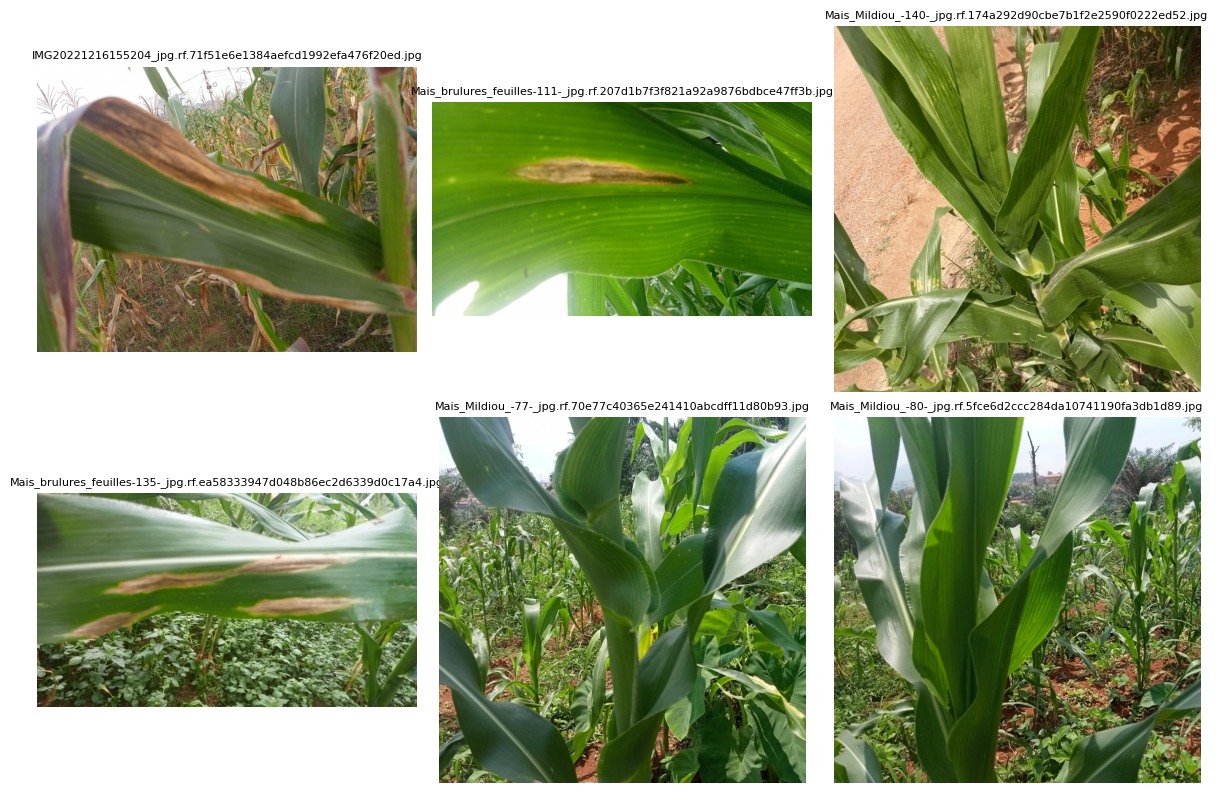

In [15]:
import matplotlib.pyplot as plt

sample_paths = fp_bucket['Maize_Northern_Leaf_Blight'][:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, path in zip(axes.flat, sample_paths):
    img = Image.open(path)
    ax.imshow(img)
    ax.set_title(os.path.basename(path), fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [16]:
FIELDPLANT_CLASS_MAP = {
    'Corn Gray leaf spot': 'Maize_Gray_Leaf_Spot',
    'Corn Healthy': 'Maize_Healthy',
    'Corn rust leaf': 'Maize_Common_Rust',
    # 'Corn leaf blight': 'Maize_Northern_Leaf_Blight',  # dropped - filenames show mixed "mildew"/"leaf burn" labels, not confirmed as blight specifically
    'Tomato healthy': 'Tomato_Healthy',
    'Tomato leaf mosaic virus': 'Tomato_Mosaic_Virus',
    'Tomato leaf yellow virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

fp_bucket = gather_fieldplant_images(fieldplant_root, FIELDPLANT_CLASS_MAP, class_id_to_name)
for cls, paths in sorted(fp_bucket.items()):
    print(f"{cls}: {len(paths)} images")

Skipped (unmapped disease only): 4756
Skipped (mixed/ambiguous labels): 160
Maize_Common_Rust: 46 images
Maize_Gray_Leaf_Spot: 30 images
Maize_Healthy: 73 images
Tomato_Healthy: 13 images
Tomato_Mosaic_Virus: 13 images
Tomato_Yellow_Leaf_Curl_Virus: 65 images


In [17]:
merged_v4 = defaultdict(list)
for bucket in (pv_bucket, pw_bucket, pd_bucket, fp_bucket):
    for cls, paths in bucket.items():
        merged_v4[cls].extend(paths)

for cls, paths in sorted(merged_v4.items()):
    print(f"{cls}: {len(paths)} combined")

MAX_PER_CLASS = 800
MIN_PER_CLASS = 50
AUGMENT_TARGET = 800

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
])

def balance_and_write(merged, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    summary = []
    for cls, paths in merged.items():
        if len(paths) < MIN_PER_CLASS:
            summary.append((cls, len(paths), 'DROPPED'))
            continue
        class_out_dir = os.path.join(output_dir, cls)
        os.makedirs(class_out_dir, exist_ok=True)

        if len(paths) > MAX_PER_CLASS:
            chosen = random.sample(paths, MAX_PER_CLASS)
            for i, src in enumerate(chosen):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, MAX_PER_CLASS, f'downsampled from {len(paths)}'))
        elif len(paths) < AUGMENT_TARGET:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_orig_{i:05d}.jpg"))
            n_needed = AUGMENT_TARGET - len(paths)
            i = 0
            while n_needed > 0:
                src = random.choice(paths)
                img = Image.open(src).convert('RGB')
                aug_img = augment_transform(img)
                aug_img.save(os.path.join(class_out_dir, f"{cls}_aug_{i:05d}.jpg"))
                i += 1
                n_needed -= 1
            summary.append((cls, AUGMENT_TARGET, f'augmented from {len(paths)}'))
        else:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, len(paths), 'used as-is'))

    print("\n--- Final class summary ---")
    for cls, count, note in sorted(summary):
        print(f"  {cls:35s} {count:5d}  ({note})")

OUTPUT_DIR_V4 = '/kaggle/working/tier1_unified_v4'
balance_and_write(merged_v4, OUTPUT_DIR_V4)

Maize_Common_Rust: 1582 combined
Maize_Gray_Leaf_Spot: 822 combined
Maize_Healthy: 1391 combined
Maize_Northern_Leaf_Blight: 1391 combined
Potato_Early_Blight: 1384 combined
Potato_Healthy: 401 combined
Potato_Late_Blight: 1440 combined
Tomato_Bacterial_Spot: 2508 combined
Tomato_Early_Blight: 1425 combined
Tomato_Healthy: 1874 combined
Tomato_Late_Blight: 2305 combined
Tomato_Leaf_Mold: 1276 combined
Tomato_Mosaic_Virus: 619 combined
Tomato_Septoria_Leaf_Spot: 2136 combined
Tomato_Spider_Mites: 1678 combined
Tomato_Target_Spot: 1404 combined
Tomato_Yellow_Leaf_Curl_Virus: 5816 combined

--- Final class summary ---
  Maize_Common_Rust                     800  (downsampled from 1582)
  Maize_Gray_Leaf_Spot                  800  (downsampled from 822)
  Maize_Healthy                         800  (downsampled from 1391)
  Maize_Northern_Leaf_Blight            800  (downsampled from 1391)
  Potato_Early_Blight                   800  (downsampled from 1384)
  Potato_Healthy                 

In [18]:
import os, random, shutil, json
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
from efficientnet_pytorch import EfficientNet
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from PIL import Image
from collections import defaultdict
import kagglehub, yaml

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [20]:
!pip install efficientnet_pytorch --quiet --no-deps

In [21]:
pv_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
PLANTVILLAGE_DIR = os.path.join(pv_path, 'color')

from huggingface_hub import snapshot_download
import zipfile
pw_snapshot = snapshot_download(repo_id="uqtwei2/PlantWild", repo_type="dataset")
pw_extract_dir = "/kaggle/working/plantwild_extracted"
os.makedirs(pw_extract_dir, exist_ok=True)
with zipfile.ZipFile(os.path.join(pw_snapshot, "plantwild.zip"), 'r') as z:
    z.extractall(pw_extract_dir)
PLANTWILD_DIR = os.path.join(pw_extract_dir, 'plantwild', 'images')

plantdoc_path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")
def find_plantdoc_root(search_from):
    for root, dirs, files in os.walk(search_from):
        if 'train' in dirs and 'test' in dirs:
            return root
    return None
plantdoc_dataset_root = find_plantdoc_root(plantdoc_path)

fieldplant_root = '/kaggle/working/FieldPlant-11'
if not os.path.isdir(fieldplant_root):
    !pip install roboflow --quiet
    from roboflow import Roboflow
    rf = Roboflow(api_key="U4BSNMZOjjYjIQlB6UkB")
    project = rf.workspace("plant-disease-detection").project("fieldplant")
    version = project.version(11)
    dataset = version.download("yolov8")
    fieldplant_root = dataset.location

print("PlantVillage:", PLANTVILLAGE_DIR)
print("PlantWild:", PLANTWILD_DIR)
print("PlantDoc:", plantdoc_dataset_root)
print("FieldPlant:", fieldplant_root)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

PlantVillage: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
PlantWild: /kaggle/working/plantwild_extracted/plantwild/images
PlantDoc: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset
FieldPlant: /kaggle/working/FieldPlant-11


In [22]:
PLANTVILLAGE_CLASS_MAP = {
    'Potato___Early_blight': 'Potato_Early_Blight', 'Potato___Late_blight': 'Potato_Late_Blight',
    'Potato___healthy': 'Potato_Healthy', 'Tomato___Bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato___Early_blight': 'Tomato_Early_Blight', 'Tomato___Late_blight': 'Tomato_Late_Blight',
    'Tomato___Leaf_Mold': 'Tomato_Leaf_Mold', 'Tomato___Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato___Spider_mites Two-spotted_spider_mite': 'Tomato_Spider_Mites',
    'Tomato___Target_Spot': 'Tomato_Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus': 'Tomato_Mosaic_Virus', 'Tomato___healthy': 'Tomato_Healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_(maize)___Common_rust_': 'Maize_Common_Rust',
    'Corn_(maize)___Northern_Leaf_Blight': 'Maize_Northern_Leaf_Blight',
    'Corn_(maize)___healthy': 'Maize_Healthy',
}

PLANTWILD_CLASS_MAP = {
    'corn gray leaf spot': 'Maize_Gray_Leaf_Spot', 'corn rust': 'Maize_Common_Rust',
    'corn northern leaf blight': 'Maize_Northern_Leaf_Blight', 'corn leaf': 'Maize_Healthy',
    'potato early blight': 'Potato_Early_Blight', 'potato late blight': 'Potato_Late_Blight',
    'potato leaf': 'Potato_Healthy', 'tomato early blight': 'Tomato_Early_Blight',
    'tomato late blight': 'Tomato_Late_Blight', 'tomato leaf mold': 'Tomato_Leaf_Mold',
    'tomato septoria leaf spot': 'Tomato_Septoria_Leaf_Spot',
    'tomato yellow leaf curl virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'tomato bacterial leaf spot': 'Tomato_Bacterial_Spot', 'tomato mosaic virus': 'Tomato_Mosaic_Virus',
    'tomato leaf': 'Tomato_Healthy',
}

PLANTDOC_CLASS_MAP = {
    'Corn_rust_leaf': 'Maize_Common_Rust', 'Corn_Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_leaf_blight': 'Maize_Northern_Leaf_Blight', 'Potato_leaf_early_blight': 'Potato_Early_Blight',
    'Potato_leaf_late_blight': 'Potato_Late_Blight', 'Tomato_leaf_bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato_Early_blight_leaf': 'Tomato_Early_Blight', 'Tomato_leaf': 'Tomato_Healthy',
    'Tomato_leaf_late_blight': 'Tomato_Late_Blight', 'Tomato_mold_leaf': 'Tomato_Leaf_Mold',
    'Tomato_leaf_mosaic_virus': 'Tomato_Mosaic_Virus', 'Tomato_Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato_two_spotted_spider_mites_leaf': 'Tomato_Spider_Mites',
    'Tomato_leaf_yellow_virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

FIELDPLANT_CLASS_MAP = {
    'Corn Gray leaf spot': 'Maize_Gray_Leaf_Spot', 'Corn Healthy': 'Maize_Healthy',
    'Corn rust leaf': 'Maize_Common_Rust',
    # 'Corn leaf blight': 'Maize_Northern_Leaf_Blight',  # dropped - unreliable mapping
    'Tomato healthy': 'Tomato_Healthy', 'Tomato leaf mosaic virus': 'Tomato_Mosaic_Virus',
    'Tomato leaf yellow virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

CLASS_NAMES = [
    'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight',
    'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight',
    'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight',
    'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot',
    'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus',
]
num_classes = len(CLASS_NAMES)

In [23]:
def gather_source_images(source_dir, class_map):
    bucket = defaultdict(list)
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(source_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
    return bucket

def gather_plantdoc_train_images(plantdoc_root, class_map):
    bucket = defaultdict(list)
    train_dir = os.path.join(plantdoc_root, 'train')
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(train_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
    return bucket

def gather_fieldplant_images(root, class_map):
    with open(os.path.join(root, 'data.yaml')) as f:
        data_yaml = yaml.safe_load(f)
    class_id_to_name = {i: name for i, name in enumerate(data_yaml['names'])}
    bucket = defaultdict(list)
    for split in ['train', 'valid', 'test']:
        images_dir = os.path.join(root, split, 'images')
        labels_dir = os.path.join(root, split, 'labels')
        if not os.path.isdir(images_dir):
            continue
        for label_file in os.listdir(labels_dir):
            if not label_file.endswith('.txt'):
                continue
            with open(os.path.join(labels_dir, label_file)) as f:
                lines = f.readlines()
            class_ids_in_image = {int(l.strip().split()[0]) for l in lines if l.strip()}
            source_names = {class_id_to_name[cid] for cid in class_ids_in_image}
            mapped_names = {n for n in source_names if n in class_map}
            if not mapped_names or len(source_names) > len(mapped_names) or len(mapped_names) > 1:
                continue
            unified_class = class_map[list(mapped_names)[0]]
            img_path = os.path.join(images_dir, label_file.replace('.txt', '.jpg'))
            if os.path.isfile(img_path):
                bucket[unified_class].append(img_path)
    return bucket

pv_bucket = gather_source_images(PLANTVILLAGE_DIR, PLANTVILLAGE_CLASS_MAP)
pw_bucket = gather_source_images(PLANTWILD_DIR, PLANTWILD_CLASS_MAP)
pd_bucket = gather_plantdoc_train_images(plantdoc_dataset_root, PLANTDOC_CLASS_MAP)
fp_bucket = gather_fieldplant_images(fieldplant_root, FIELDPLANT_CLASS_MAP)

merged_v4 = defaultdict(list)
for bucket in (pv_bucket, pw_bucket, pd_bucket, fp_bucket):
    for cls, paths in bucket.items():
        merged_v4[cls].extend(paths)
for cls, paths in sorted(merged_v4.items()):
    print(f"{cls}: {len(paths)} combined")

Maize_Common_Rust: 1582 combined
Maize_Gray_Leaf_Spot: 822 combined
Maize_Healthy: 1391 combined
Maize_Northern_Leaf_Blight: 1391 combined
Potato_Early_Blight: 1384 combined
Potato_Healthy: 401 combined
Potato_Late_Blight: 1440 combined
Tomato_Bacterial_Spot: 2508 combined
Tomato_Early_Blight: 1425 combined
Tomato_Healthy: 1874 combined
Tomato_Late_Blight: 2305 combined
Tomato_Leaf_Mold: 1276 combined
Tomato_Mosaic_Virus: 619 combined
Tomato_Septoria_Leaf_Spot: 2136 combined
Tomato_Spider_Mites: 1678 combined
Tomato_Target_Spot: 1404 combined
Tomato_Yellow_Leaf_Curl_Virus: 5816 combined


In [24]:
MAX_PER_CLASS = 800
MIN_PER_CLASS = 50
AUGMENT_TARGET = 800

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
])

def balance_and_write(merged, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    summary = []
    for cls, paths in merged.items():
        if len(paths) < MIN_PER_CLASS:
            summary.append((cls, len(paths), 'DROPPED'))
            continue
        class_out_dir = os.path.join(output_dir, cls)
        os.makedirs(class_out_dir, exist_ok=True)
        if len(paths) > MAX_PER_CLASS:
            chosen = random.sample(paths, MAX_PER_CLASS)
            for i, src in enumerate(chosen):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, MAX_PER_CLASS, f'downsampled from {len(paths)}'))
        elif len(paths) < AUGMENT_TARGET:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_orig_{i:05d}.jpg"))
            n_needed = AUGMENT_TARGET - len(paths)
            i = 0
            while n_needed > 0:
                src = random.choice(paths)
                img = Image.open(src).convert('RGB')
                aug_img = augment_transform(img)
                aug_img.save(os.path.join(class_out_dir, f"{cls}_aug_{i:05d}.jpg"))
                i += 1; n_needed -= 1
            summary.append((cls, AUGMENT_TARGET, f'augmented from {len(paths)}'))
        else:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, len(paths), 'used as-is'))
    print("\n--- Final class summary ---")
    for cls, count, note in sorted(summary):
        print(f"  {cls:35s} {count:5d}  ({note})")

OUTPUT_DIR_V4 = '/kaggle/working/tier1_unified_v4'
balance_and_write(merged_v4, OUTPUT_DIR_V4)


--- Final class summary ---
  Maize_Common_Rust                     800  (downsampled from 1582)
  Maize_Gray_Leaf_Spot                  800  (downsampled from 822)
  Maize_Healthy                         800  (downsampled from 1391)
  Maize_Northern_Leaf_Blight            800  (downsampled from 1391)
  Potato_Early_Blight                   800  (downsampled from 1384)
  Potato_Healthy                        800  (augmented from 401)
  Potato_Late_Blight                    800  (downsampled from 1440)
  Tomato_Bacterial_Spot                 800  (downsampled from 2508)
  Tomato_Early_Blight                   800  (downsampled from 1425)
  Tomato_Healthy                        800  (downsampled from 1874)
  Tomato_Late_Blight                    800  (downsampled from 2305)
  Tomato_Leaf_Mold                      800  (downsampled from 1276)
  Tomato_Mosaic_Virus                   800  (augmented from 619)
  Tomato_Septoria_Leaf_Spot             800  (downsampled from 2136)
  Tomato_Spi

In [25]:
SAVE_DIR = '/kaggle/working/models'
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, 'tier1_v4_with_fieldplant.pth')

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 30
PATIENCE = 6
FREEZE_UNTIL_BLOCK = -4

In [26]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset_aug = datasets.ImageFolder(OUTPUT_DIR_V4, transform=train_transform)
full_dataset_plain = datasets.ImageFolder(OUTPUT_DIR_V4, transform=eval_transform)
print(f"Classes ({len(full_dataset_aug.classes)}): {full_dataset_aug.classes}")

targets = np.array(full_dataset_aug.targets)
indices = np.arange(len(targets))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=targets, random_state=SEED)
train_subset = Subset(full_dataset_aug, train_idx)
val_subset = Subset(full_dataset_plain, val_idx)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train_labels = targets[train_idx]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

Classes (17): ['Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot', 'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus']


In [27]:
model = EfficientNet.from_pretrained('efficientnet-b0')
model._fc = nn.Linear(model._fc.in_features, len(full_dataset_aug.classes))
for param in model.parameters():
    param.requires_grad = False
for block in model._blocks[FREEZE_UNTIL_BLOCK:]:
    for param in block.parameters():
        param.requires_grad = True
for param in model._fc.parameters():
    param.requires_grad = True
for param in model._conv_head.parameters():
    param.requires_grad = True
for param in model._bn1.parameters():
    param.requires_grad = True
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b0-355c32eb.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b0-355c32eb.pth


100%|██████████| 20.4M/20.4M [00:00<00:00, 102MB/s] 

Loaded pretrained weights for efficientnet-b0


In [28]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward(); optimizer.step()
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    return running_loss / len(loader.dataset), correct / total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return running_loss / len(loader.dataset), correct / total, macro_f1, all_preds, all_labels

In [31]:
from IPython.display import FileLink, display

best_f1 = 0.0
epochs_no_improve = 0
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step()
    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f} Macro-F1: {val_f1:.4f}")
    if val_f1 > best_f1:
        best_f1 = val_f1; epochs_no_improve = 0
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"  -> saved (Val Macro-F1: {val_f1:.4f})")
        display(FileLink(SAVE_PATH))
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch+1}")
            break

Epoch 1/30 | Train Loss: 0.1106 Acc: 0.9631 | Val Loss: 0.3334 Acc: 0.8993 Macro-F1: 0.8989
  -> saved (Val Macro-F1: 0.8989)


/kaggle/working/models/tier1_v4_with_fieldplant.pth

Epoch 2/30 | Train Loss: 0.1053 Acc: 0.9661 | Val Loss: 0.3413 Acc: 0.9026 Macro-F1: 0.9026
  -> saved (Val Macro-F1: 0.9026)


/kaggle/working/models/tier1_v4_with_fieldplant.pth

Epoch 3/30 | Train Loss: 0.1005 Acc: 0.9686 | Val Loss: 0.3341 Acc: 0.9051 Macro-F1: 0.9048
  -> saved (Val Macro-F1: 0.9048)


/kaggle/working/models/tier1_v4_with_fieldplant.pth

Epoch 4/30 | Train Loss: 0.0889 Acc: 0.9717 | Val Loss: 0.3387 Acc: 0.9051 Macro-F1: 0.9052
  -> saved (Val Macro-F1: 0.9052)


/kaggle/working/models/tier1_v4_with_fieldplant.pth

Epoch 5/30 | Train Loss: 0.0910 Acc: 0.9712 | Val Loss: 0.3396 Acc: 0.9040 Macro-F1: 0.9040
Epoch 6/30 | Train Loss: 0.0842 Acc: 0.9733 | Val Loss: 0.3425 Acc: 0.9022 Macro-F1: 0.9021
Epoch 7/30 | Train Loss: 0.0851 Acc: 0.9721 | Val Loss: 0.3404 Acc: 0.9040 Macro-F1: 0.9040
Epoch 8/30 | Train Loss: 0.0833 Acc: 0.9736 | Val Loss: 0.3420 Acc: 0.9048 Macro-F1: 0.9046
Epoch 9/30 | Train Loss: 0.0780 Acc: 0.9760 | Val Loss: 0.3454 Acc: 0.9026 Macro-F1: 0.9024
Epoch 10/30 | Train Loss: 0.0762 Acc: 0.9763 | Val Loss: 0.3444 Acc: 0.9022 Macro-F1: 0.9020
Early stopping at epoch 10


In [32]:
model.load_state_dict(torch.load(SAVE_PATH, weights_only=True))
_, _, _, all_preds, all_labels = evaluate(model, val_loader, criterion, device)
print(classification_report(all_labels, all_preds, target_names=full_dataset_aug.classes))

                               precision    recall  f1-score   support

            Maize_Common_Rust       0.96      0.95      0.95       160
         Maize_Gray_Leaf_Spot       0.80      0.86      0.83       160
                Maize_Healthy       0.96      0.97      0.97       160
   Maize_Northern_Leaf_Blight       0.86      0.79      0.82       160
          Potato_Early_Blight       0.88      0.90      0.89       160
               Potato_Healthy       0.94      0.94      0.94       160
           Potato_Late_Blight       0.93      0.85      0.89       160
        Tomato_Bacterial_Spot       0.88      0.90      0.89       160
          Tomato_Early_Blight       0.80      0.83      0.81       160
               Tomato_Healthy       0.94      0.97      0.95       160
           Tomato_Late_Blight       0.87      0.91      0.89       160
             Tomato_Leaf_Mold       0.95      0.91      0.93       160
          Tomato_Mosaic_Virus       0.87      0.93      0.89       160
    T

In [33]:
class PlantDocTestOnlyDataset(Dataset):
    def __init__(self, plantdoc_root, class_map, class_names, transform):
        self.samples = []
        self.transform = transform
        test_dir = os.path.join(plantdoc_root, 'test')
        for source_class, unified_class in class_map.items():
            class_dir = os.path.join(test_dir, source_class)
            if not os.path.isdir(class_dir):
                print(f"  WARNING: not found: {class_dir}")
                continue
            label_idx = class_names.index(unified_class)
            for fname in os.listdir(class_dir):
                if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                    self.samples.append((os.path.join(class_dir, fname), label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        return self.transform(image), label

plantdoc_test_only = PlantDocTestOnlyDataset(plantdoc_dataset_root, PLANTDOC_CLASS_MAP, CLASS_NAMES, eval_transform)
print(f"Total test-only PlantDoc images: {len(plantdoc_test_only)}")

plantdoc_test_loader = DataLoader(plantdoc_test_only, batch_size=32, shuffle=False, num_workers=2)

Total test-only PlantDoc images: 127


In [34]:
model.eval()
all_preds_v4, all_labels_v4 = [], []
with torch.no_grad():
    for inputs, labels in plantdoc_test_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds_v4.extend(preds.cpu().numpy())
        all_labels_v4.extend(labels.numpy())

print(f"Collected {len(all_labels_v4)} predictions")

present_labels_v4 = sorted(set(all_labels_v4))
present_names_v4 = [CLASS_NAMES[i] for i in present_labels_v4]

print("--- PlantDoc TEST-ONLY evaluation (v4 model - PlantVillage+PlantWild+PlantDoc+FieldPlant) ---")
print(classification_report(all_labels_v4, all_preds_v4, labels=present_labels_v4, target_names=present_names_v4))

Collected 127 predictions
--- PlantDoc TEST-ONLY evaluation (v4 model - PlantVillage+PlantWild+PlantDoc+FieldPlant) ---
                               precision    recall  f1-score   support

            Maize_Common_Rust       1.00      0.80      0.89        10
         Maize_Gray_Leaf_Spot       0.23      0.75      0.35         4
   Maize_Northern_Leaf_Blight       0.80      0.33      0.47        12
          Potato_Early_Blight       0.50      0.29      0.36        14
           Potato_Late_Blight       0.38      0.75      0.50         8
        Tomato_Bacterial_Spot       0.33      0.33      0.33         9
          Tomato_Early_Blight       0.57      0.89      0.70         9
               Tomato_Healthy       0.83      0.62      0.71         8
           Tomato_Late_Blight       0.57      0.40      0.47        10
             Tomato_Leaf_Mold       0.40      0.67      0.50         6
          Tomato_Mosaic_Virus       0.50      0.80      0.62        10
    Tomato_Septoria_Leaf_Sp

# Tier 2

In [15]:
!pip install kaggle --quiet

import os
os.environ['KAGGLE_USERNAME'] = 'gulshan07'  # your username
# You need a Kaggle API key for competition downloads specifically -
# regular dataset_download doesn't need this, but competitions do.

In [16]:
!kaggle competitions download -c paddy-disease-classification -p /kaggle/working/paddydoctor

import zipfile
with zipfile.ZipFile('/kaggle/working/paddydoctor/paddy-disease-classification.zip', 'r') as z:
    z.extractall('/kaggle/working/paddydoctor')

paddydoctor_path = '/kaggle/working/paddydoctor'
print("Extracted to:", paddydoctor_path)

paddy-disease-classification.zip: Skipping, found more recently modified local copy (use --force to force download)
Extracted to: /kaggle/working/paddydoctor


In [17]:
def discover(root, label, max_depth=3):
    print(f"\n=== {label}: {root} ===")
    for r, dirs, files in os.walk(root):
        level = r.replace(root, '').count(os.sep)
        if level > max_depth:
            dirs[:] = []
            continue
        indent = '  ' * level
        print(f"{indent}{os.path.basename(r)}/")
        for f in files[:3]:
            print(f"{indent}  {f}")

discover(paddydoctor_path, "PaddyDoctor")

dhanshomadhan_path = kagglehub.dataset_download("nirmalsankalana/dhan-shomadhan")
discover(dhanshomadhan_path, "DhanShomadhan")

wheatlong_path = kagglehub.dataset_download("yasserhessein/wheat-disease-dataset-small")
discover(wheatlong_path, "WheatLong")


=== PaddyDoctor: /kaggle/working/paddydoctor ===
paddydoctor/
  train.csv
  sample_submission.csv
  paddy-disease-classification.zip
  train_images/
    blast/
      107564.jpg
      102223.jpg
      104832.jpg
    hispa/
      104537.jpg
      105601.jpg
      107223.jpg
    downy_mildew/
      101361.jpg
      109729.jpg
      106138.jpg
    bacterial_leaf_blight/
      108765.jpg
      103615.jpg
      106339.jpg
    normal/
      103302.jpg
      107098.jpg
      106282.jpg
    tungro/
      101389.jpg
      105160.jpg
      102037.jpg
    bacterial_panicle_blight/
      101281.jpg
      101597.jpg
      100251.jpg
    dead_heart/
      101065.jpg
      107623.jpg
      109221.jpg
    brown_spot/
      101353.jpg
      106660.jpg
      102082.jpg
    bacterial_leaf_streak/
      100178.jpg
      107570.jpg
      103325.jpg
  test_images/
    203182.jpg
    202739.jpg
    201031.jpg

=== DhanShomadhan: /kaggle/input/datasets/nirmalsankalana/dhan-shomadhan ===
dhan-shomadhan/
  Rice

Exists: True


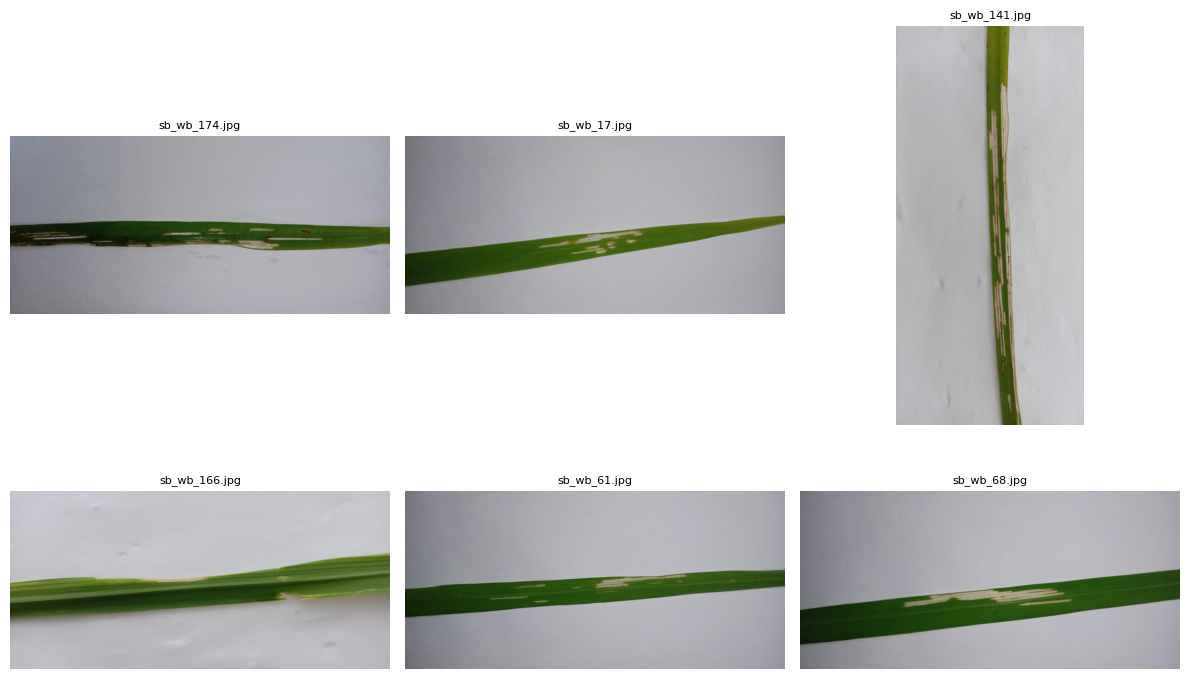

In [18]:
sample_dir = os.path.join(dhanshomadhan_path, 'Rice___bacterial_blight')
print("Exists:", os.path.isdir(sample_dir))

sample_files = os.listdir(sample_dir)[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, fname in zip(axes.flat, sample_files):
    img = Image.open(os.path.join(sample_dir, fname))
    ax.imshow(img)
    ax.set_title(fname, fontsize=8)
    ax.axis('off')
plt.tight_layout()
plt.show()

In [19]:
"""
Tier 2 - Rice + Wheat gather and mapping
Run after tier2_01_discover.py has confirmed paths. Adds 12 rice classes
(from PaddyDoctor + DhanShomadhan, merged where they overlap) and 5 wheat
classes (from WheatLong) to your existing 17-class Tier 1 taxonomy.

IMPORTANT: DhanShomadhan's 'Rice___bacterial_blight' folder is relabeled to
Rice_Sheath_Blight here - the dataset's own paper lists Sheath Blight as one
of its 5 diseases and does not mention bacterial blight at all; the 'sb_'
filename prefix supports this too. Treating the Kaggle mirror's folder name
as the error, not the paper.
"""

import os
from collections import defaultdict

# ---------------------------------------------------------------------------
# PaddyDoctor mapping - straightforward, folder names ARE the disease names
# ---------------------------------------------------------------------------
PADDYDOCTOR_CLASS_MAP = {
    'bacterial_leaf_blight': 'Rice_Bacterial_Leaf_Blight',
    'bacterial_leaf_streak': 'Rice_Bacterial_Leaf_Streak',
    'bacterial_panicle_blight': 'Rice_Bacterial_Panicle_Blight',
    'blast': 'Rice_Blast',
    'brown_spot': 'Rice_Brown_Spot',
    'dead_heart': 'Rice_Dead_Heart',
    'downy_mildew': 'Rice_Downy_Mildew',
    'hispa': 'Rice_Hispa',
    'tungro': 'Rice_Tungro',
    'normal': 'Rice_Healthy',
}

# ---------------------------------------------------------------------------
# DhanShomadhan mapping - note the corrected bacterial_blight -> Sheath_Blight
# ---------------------------------------------------------------------------
DHANSHOMADHAN_CLASS_MAP = {
    'Rice___blast': 'Rice_Blast',
    'Rice___tungro': 'Rice_Tungro',
    'Rice___brown_spot': 'Rice_Brown_Spot',
    'Rice___leaf_scald': 'Rice_Leaf_Scald',
    'Rice___bacterial_blight': 'Rice_Sheath_Blight',  # corrected - see docstring above
}

# ---------------------------------------------------------------------------
# WheatLong mapping
# ---------------------------------------------------------------------------
WHEATLONG_CLASS_MAP = {
    'Mildew': 'Wheat_Mildew',
    'YellowRust': 'Wheat_Yellow_Rust',
    'Septoria': 'Wheat_Septoria',
    'Healthy': 'Wheat_Healthy',
    'BrownRust': 'Wheat_Brown_Rust',
}

# ---------------------------------------------------------------------------
# Gather functions - same pattern as Tier 1
# ---------------------------------------------------------------------------
def gather_class_folders(root, class_map):
    bucket = defaultdict(list)
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(root, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        n_added = 0
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
                n_added += 1
        print(f"  {source_class}: {n_added} images")
    return bucket

# PaddyDoctor's real root has train_images/ as the class-folder parent
paddydoctor_train_root = os.path.join(paddydoctor_path, 'train_images')
pdoc_bucket = gather_class_folders(paddydoctor_train_root, PADDYDOCTOR_CLASS_MAP)

dhan_bucket = gather_class_folders(dhanshomadhan_path, DHANSHOMADHAN_CLASS_MAP)

# WheatLong has an extra 'Wheat Disease Dataset' nesting level
wheatlong_root = os.path.join(wheatlong_path, 'Wheat Disease Dataset')
wheat_bucket = gather_class_folders(wheatlong_root, WHEATLONG_CLASS_MAP)

# ---------------------------------------------------------------------------
# Merge rice sources (PaddyDoctor + DhanShomadhan combine on overlapping classes)
# ---------------------------------------------------------------------------
rice_merged = defaultdict(list)
for bucket in (pdoc_bucket, dhan_bucket):
    for cls, paths in bucket.items():
        rice_merged[cls].extend(paths)

print("\n--- Rice combined counts ---")
for cls, paths in sorted(rice_merged.items()):
    print(f"{cls}: {len(paths)} combined")

print("\n--- Wheat counts ---")
for cls, paths in sorted(wheat_bucket.items()):
    print(f"{cls}: {len(paths)}")

  bacterial_leaf_blight: 479 images
  bacterial_leaf_streak: 380 images
  bacterial_panicle_blight: 337 images
  blast: 1738 images
  brown_spot: 965 images
  dead_heart: 1442 images
  downy_mildew: 620 images
  hispa: 1594 images
  tungro: 1088 images
  normal: 1764 images
  Rice___blast: 198 images
  Rice___tungro: 119 images
  Rice___brown_spot: 90 images
  Rice___leaf_scald: 143 images
  Rice___bacterial_blight: 219 images
  Mildew: 161 images
  YellowRust: 239 images
  Septoria: 349 images
  Healthy: 122 images
  BrownRust: 128 images

--- Rice combined counts ---
Rice_Bacterial_Leaf_Blight: 479 combined
Rice_Bacterial_Leaf_Streak: 380 combined
Rice_Bacterial_Panicle_Blight: 337 combined
Rice_Blast: 1936 combined
Rice_Brown_Spot: 1055 combined
Rice_Dead_Heart: 1442 combined
Rice_Downy_Mildew: 620 combined
Rice_Healthy: 1764 combined
Rice_Hispa: 1594 combined
Rice_Leaf_Scald: 143 combined
Rice_Sheath_Blight: 219 combined
Rice_Tungro: 1207 combined

--- Wheat counts ---
Wheat_Brown_

In [20]:
print('pv_bucket' in dir(), 'pw_bucket' in dir(), 'pd_bucket' in dir(), 'fp_bucket' in dir())

False False False False


In [13]:
import kagglehub
from huggingface_hub import snapshot_download
import zipfile

pv_path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")
PLANTVILLAGE_DIR = os.path.join(pv_path, 'color')

pw_extract_dir = "/kaggle/working/plantwild_extracted"
if not os.path.isdir(pw_extract_dir):
    pw_snapshot = snapshot_download(repo_id="uqtwei2/PlantWild", repo_type="dataset")
    os.makedirs(pw_extract_dir, exist_ok=True)
    with zipfile.ZipFile(os.path.join(pw_snapshot, "plantwild.zip"), 'r') as z:
        z.extractall(pw_extract_dir)
PLANTWILD_DIR = os.path.join(pw_extract_dir, 'plantwild', 'images')

plantdoc_path = kagglehub.dataset_download("nirmalsankalana/plantdoc-dataset")
def find_plantdoc_root(search_from):
    for root, dirs, files in os.walk(search_from):
        if 'train' in dirs and 'test' in dirs:
            return root
    return None
plantdoc_dataset_root = find_plantdoc_root(plantdoc_path)

fieldplant_root = '/kaggle/working/FieldPlant-11'
if not os.path.isdir(fieldplant_root):
    !pip install roboflow --quiet
    from roboflow import Roboflow
    rf = Roboflow(api_key="U4BSNMZOjjYjIQlB6UkB")
    project = rf.workspace("plant-disease-detection").project("fieldplant")
    version = project.version(11)
    dataset = version.download("yolov8")
    fieldplant_root = dataset.location

print("PlantVillage:", PLANTVILLAGE_DIR)
print("PlantWild:", PLANTWILD_DIR)
print("PlantDoc:", plantdoc_dataset_root)
print("FieldPlant:", fieldplant_root)

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 4.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 28.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 89.3 MB/s eta 0:00:00ta 0:00:01
loading Roboflow workspace...
loading Roboflow project...




Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   0%|          | 0/10318 [00:00<?, ?it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   0%|          | 46/10318 [00:00<00:22, 454.08it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   1%|          | 92/10318 [00:00<00:23, 428.62it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   1%|▏         | 141/10318 [00:00<00:22, 454.27it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   2%|▏         | 199/10318 [00:00<00:20, 500.07it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   2%|▏         | 253/10318 [00:00<00:19, 513.42it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   3%|▎         | 312/10318 [00:00<00:18, 537.91it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   4%|▎         | 374/10318 [00:00<00:17, 562.36it/s]
Extracting Dataset Version Zip to FieldPlant-11 in yolov8::   4%|▍         | 440/10318 [00:00<00:16, 591.85

PlantVillage: /kaggle/input/datasets/abdallahalidev/plantvillage-dataset/color
PlantWild: /kaggle/working/plantwild_extracted/plantwild/images
PlantDoc: /kaggle/input/datasets/nirmalsankalana/plantdoc-dataset
FieldPlant: /kaggle/working/FieldPlant-11


In [22]:
from collections import defaultdict
import yaml

PLANTVILLAGE_CLASS_MAP = {
    'Potato___Early_blight': 'Potato_Early_Blight', 'Potato___Late_blight': 'Potato_Late_Blight',
    'Potato___healthy': 'Potato_Healthy', 'Tomato___Bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato___Early_blight': 'Tomato_Early_Blight', 'Tomato___Late_blight': 'Tomato_Late_Blight',
    'Tomato___Leaf_Mold': 'Tomato_Leaf_Mold', 'Tomato___Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato___Spider_mites Two-spotted_spider_mite': 'Tomato_Spider_Mites',
    'Tomato___Target_Spot': 'Tomato_Target_Spot',
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato___Tomato_mosaic_virus': 'Tomato_Mosaic_Virus', 'Tomato___healthy': 'Tomato_Healthy',
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_(maize)___Common_rust_': 'Maize_Common_Rust',
    'Corn_(maize)___Northern_Leaf_Blight': 'Maize_Northern_Leaf_Blight',
    'Corn_(maize)___healthy': 'Maize_Healthy',
}

PLANTWILD_CLASS_MAP = {
    'corn gray leaf spot': 'Maize_Gray_Leaf_Spot', 'corn rust': 'Maize_Common_Rust',
    'corn northern leaf blight': 'Maize_Northern_Leaf_Blight', 'corn leaf': 'Maize_Healthy',
    'potato early blight': 'Potato_Early_Blight', 'potato late blight': 'Potato_Late_Blight',
    'potato leaf': 'Potato_Healthy', 'tomato early blight': 'Tomato_Early_Blight',
    'tomato late blight': 'Tomato_Late_Blight', 'tomato leaf mold': 'Tomato_Leaf_Mold',
    'tomato septoria leaf spot': 'Tomato_Septoria_Leaf_Spot',
    'tomato yellow leaf curl virus': 'Tomato_Yellow_Leaf_Curl_Virus',
    'tomato bacterial leaf spot': 'Tomato_Bacterial_Spot', 'tomato mosaic virus': 'Tomato_Mosaic_Virus',
    'tomato leaf': 'Tomato_Healthy',
}

PLANTDOC_CLASS_MAP = {
    'Corn_rust_leaf': 'Maize_Common_Rust', 'Corn_Gray_leaf_spot': 'Maize_Gray_Leaf_Spot',
    'Corn_leaf_blight': 'Maize_Northern_Leaf_Blight', 'Potato_leaf_early_blight': 'Potato_Early_Blight',
    'Potato_leaf_late_blight': 'Potato_Late_Blight', 'Tomato_leaf_bacterial_spot': 'Tomato_Bacterial_Spot',
    'Tomato_Early_blight_leaf': 'Tomato_Early_Blight', 'Tomato_leaf': 'Tomato_Healthy',
    'Tomato_leaf_late_blight': 'Tomato_Late_Blight', 'Tomato_mold_leaf': 'Tomato_Leaf_Mold',
    'Tomato_leaf_mosaic_virus': 'Tomato_Mosaic_Virus', 'Tomato_Septoria_leaf_spot': 'Tomato_Septoria_Leaf_Spot',
    'Tomato_two_spotted_spider_mites_leaf': 'Tomato_Spider_Mites',
    'Tomato_leaf_yellow_virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

FIELDPLANT_CLASS_MAP = {
    'Corn Gray leaf spot': 'Maize_Gray_Leaf_Spot', 'Corn Healthy': 'Maize_Healthy',
    'Corn rust leaf': 'Maize_Common_Rust',
    'Tomato healthy': 'Tomato_Healthy', 'Tomato leaf mosaic virus': 'Tomato_Mosaic_Virus',
    'Tomato leaf yellow virus': 'Tomato_Yellow_Leaf_Curl_Virus',
}

def gather_source_images(source_dir, class_map):
    bucket = defaultdict(list)
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(source_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
    return bucket

def gather_plantdoc_train_images(plantdoc_root, class_map):
    bucket = defaultdict(list)
    train_dir = os.path.join(plantdoc_root, 'train')
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(train_dir, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
    return bucket

def gather_fieldplant_images(root, class_map):
    with open(os.path.join(root, 'data.yaml')) as f:
        data_yaml = yaml.safe_load(f)
    class_id_to_name = {i: name for i, name in enumerate(data_yaml['names'])}
    bucket = defaultdict(list)
    for split in ['train', 'valid', 'test']:
        images_dir = os.path.join(root, split, 'images')
        labels_dir = os.path.join(root, split, 'labels')
        if not os.path.isdir(images_dir):
            continue
        for label_file in os.listdir(labels_dir):
            if not label_file.endswith('.txt'):
                continue
            with open(os.path.join(labels_dir, label_file)) as f:
                lines = f.readlines()
            class_ids_in_image = {int(l.strip().split()[0]) for l in lines if l.strip()}
            source_names = {class_id_to_name[cid] for cid in class_ids_in_image}
            mapped_names = {n for n in source_names if n in class_map}
            if not mapped_names or len(source_names) > len(mapped_names) or len(mapped_names) > 1:
                continue
            unified_class = class_map[list(mapped_names)[0]]
            img_path = os.path.join(images_dir, label_file.replace('.txt', '.jpg'))
            if os.path.isfile(img_path):
                bucket[unified_class].append(img_path)
    return bucket

pv_bucket = gather_source_images(PLANTVILLAGE_DIR, PLANTVILLAGE_CLASS_MAP)
pw_bucket = gather_source_images(PLANTWILD_DIR, PLANTWILD_CLASS_MAP)
pd_bucket = gather_plantdoc_train_images(plantdoc_dataset_root, PLANTDOC_CLASS_MAP)
fp_bucket = gather_fieldplant_images(fieldplant_root, FIELDPLANT_CLASS_MAP)

print("Recovered:", 'pv_bucket' in dir(), 'pw_bucket' in dir(), 'pd_bucket' in dir(), 'fp_bucket' in dir())

Recovered: True True True True


In [23]:
"""
Tier 2 - Rice + Wheat acquisition and discovery
Add this as a new section in your existing notebook - reuses device, imports,
and infrastructure already set up. Discovery-first, same discipline as Tier 1:
don't map anything until we've seen the real folder structure.
"""

import os
import kagglehub

# ---------------------------------------------------------------------------
# Download all three new sources
# ---------------------------------------------------------------------------
paddydoctor_path = kagglehub.dataset_download("paddy-disease-classification")
# NOTE: competition datasets sometimes need the full competition slug - if this
# fails, try: kagglehub.competition_download("paddy-disease-classification")

dhanshomadhan_path = kagglehub.dataset_download("nirmalsankalana/dhan-shomadhan")

wheatlong_path = kagglehub.dataset_download("yasserhessein/wheat-disease-dataset-small")

print("PaddyDoctor:", paddydoctor_path)
print("DhanShomadhan:", dhanshomadhan_path)
print("WheatLong:", wheatlong_path)

# ---------------------------------------------------------------------------
# Discover real structure for each - do NOT assume, look
# ---------------------------------------------------------------------------
def discover(root, label, max_depth=3):
    print(f"\n=== {label}: {root} ===")
    for r, dirs, files in os.walk(root):
        level = r.replace(root, '').count(os.sep)
        if level > max_depth:
            dirs[:] = []
            continue
        indent = '  ' * level
        print(f"{indent}{os.path.basename(r)}/")
        for f in files[:3]:
            print(f"{indent}  {f}")

discover(paddydoctor_path, "PaddyDoctor")
discover(dhanshomadhan_path, "DhanShomadhan")
discover(wheatlong_path, "WheatLong")

ValueError: Invalid dataset handle: paddy-disease-classification

In [24]:
"""
Tier 2 - Rice + Wheat gather and mapping
Run after tier2_01_discover.py has confirmed paths. Adds 12 rice classes
(from PaddyDoctor + DhanShomadhan, merged where they overlap) and 5 wheat
classes (from WheatLong) to your existing 17-class Tier 1 taxonomy.

IMPORTANT: DhanShomadhan's 'Rice___bacterial_blight' folder is relabeled to
Rice_Sheath_Blight here - the dataset's own paper lists Sheath Blight as one
of its 5 diseases and does not mention bacterial blight at all; the 'sb_'
filename prefix supports this too. Treating the Kaggle mirror's folder name
as the error, not the paper.
"""

import os
from collections import defaultdict

# ---------------------------------------------------------------------------
# PaddyDoctor mapping - straightforward, folder names ARE the disease names
# ---------------------------------------------------------------------------
PADDYDOCTOR_CLASS_MAP = {
    'bacterial_leaf_blight': 'Rice_Bacterial_Leaf_Blight',
    'bacterial_leaf_streak': 'Rice_Bacterial_Leaf_Streak',
    'bacterial_panicle_blight': 'Rice_Bacterial_Panicle_Blight',
    'blast': 'Rice_Blast',
    'brown_spot': 'Rice_Brown_Spot',
    'dead_heart': 'Rice_Dead_Heart',
    'downy_mildew': 'Rice_Downy_Mildew',
    'hispa': 'Rice_Hispa',
    'tungro': 'Rice_Tungro',
    'normal': 'Rice_Healthy',
}

# ---------------------------------------------------------------------------
# DhanShomadhan mapping - note the corrected bacterial_blight -> Sheath_Blight
# ---------------------------------------------------------------------------
DHANSHOMADHAN_CLASS_MAP = {
    'Rice___blast': 'Rice_Blast',
    'Rice___tungro': 'Rice_Tungro',
    'Rice___brown_spot': 'Rice_Brown_Spot',
    'Rice___leaf_scald': 'Rice_Leaf_Scald',
    'Rice___bacterial_blight': 'Rice_Sheath_Blight',  # corrected - see docstring above
}

# ---------------------------------------------------------------------------
# WheatLong mapping
# ---------------------------------------------------------------------------
WHEATLONG_CLASS_MAP = {
    'Mildew': 'Wheat_Mildew',
    'YellowRust': 'Wheat_Yellow_Rust',
    'Septoria': 'Wheat_Septoria',
    'Healthy': 'Wheat_Healthy',
    'BrownRust': 'Wheat_Brown_Rust',
}

# ---------------------------------------------------------------------------
# Gather functions - same pattern as Tier 1
# ---------------------------------------------------------------------------
def gather_class_folders(root, class_map):
    bucket = defaultdict(list)
    for source_class, unified_class in class_map.items():
        class_dir = os.path.join(root, source_class)
        if not os.path.isdir(class_dir):
            print(f"  WARNING: not found: {class_dir}")
            continue
        n_added = 0
        for fname in os.listdir(class_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                bucket[unified_class].append(os.path.join(class_dir, fname))
                n_added += 1
        print(f"  {source_class}: {n_added} images")
    return bucket

# PaddyDoctor's real root has train_images/ as the class-folder parent
paddydoctor_train_root = os.path.join(paddydoctor_path, 'train_images')
pdoc_bucket = gather_class_folders(paddydoctor_train_root, PADDYDOCTOR_CLASS_MAP)

dhan_bucket = gather_class_folders(dhanshomadhan_path, DHANSHOMADHAN_CLASS_MAP)

# WheatLong has an extra 'Wheat Disease Dataset' nesting level
wheatlong_root = os.path.join(wheatlong_path, 'Wheat Disease Dataset')
wheat_bucket = gather_class_folders(wheatlong_root, WHEATLONG_CLASS_MAP)

# ---------------------------------------------------------------------------
# Merge rice sources (PaddyDoctor + DhanShomadhan combine on overlapping classes)
# ---------------------------------------------------------------------------
rice_merged = defaultdict(list)
for bucket in (pdoc_bucket, dhan_bucket):
    for cls, paths in bucket.items():
        rice_merged[cls].extend(paths)

print("\n--- Rice combined counts ---")
for cls, paths in sorted(rice_merged.items()):
    print(f"{cls}: {len(paths)} combined")

print("\n--- Wheat counts ---")
for cls, paths in sorted(wheat_bucket.items()):
    print(f"{cls}: {len(paths)}")

  bacterial_leaf_blight: 479 images
  bacterial_leaf_streak: 380 images
  bacterial_panicle_blight: 337 images
  blast: 1738 images
  brown_spot: 965 images
  dead_heart: 1442 images
  downy_mildew: 620 images
  hispa: 1594 images
  tungro: 1088 images
  normal: 1764 images
  Rice___blast: 198 images
  Rice___tungro: 119 images
  Rice___brown_spot: 90 images
  Rice___leaf_scald: 143 images
  Rice___bacterial_blight: 219 images
  Mildew: 161 images
  YellowRust: 239 images
  Septoria: 349 images
  Healthy: 122 images
  BrownRust: 128 images

--- Rice combined counts ---
Rice_Bacterial_Leaf_Blight: 479 combined
Rice_Bacterial_Leaf_Streak: 380 combined
Rice_Bacterial_Panicle_Blight: 337 combined
Rice_Blast: 1936 combined
Rice_Brown_Spot: 1055 combined
Rice_Dead_Heart: 1442 combined
Rice_Downy_Mildew: 620 combined
Rice_Healthy: 1764 combined
Rice_Hispa: 1594 combined
Rice_Leaf_Scald: 143 combined
Rice_Sheath_Blight: 219 combined
Rice_Tungro: 1207 combined

--- Wheat counts ---
Wheat_Brown_

In [27]:
"""
Tier 2 - Full merge and balance
Combines your existing Tier 1 four-source gather (pv_bucket, pw_bucket,
pd_bucket, fp_bucket - already in memory from earlier) with the new
rice_merged and wheat_bucket, into one 34-class balanced dataset.

Requires pv_bucket, pw_bucket, pd_bucket, fp_bucket, rice_merged, wheat_bucket
all already in memory. If any are missing (fresh session), regather them
using the same functions from earlier in this notebook before running this.
"""

import random
import shutil
from PIL import Image
from torchvision import transforms

random.seed(42)

# ---------------------------------------------------------------------------
# Merge everything - Tier 1's 4 sources + rice (2 sources already merged) + wheat
# ---------------------------------------------------------------------------
merged_v5 = defaultdict(list)
for bucket in (pv_bucket, pw_bucket, pd_bucket, fp_bucket, rice_merged, wheat_bucket):
    for cls, paths in bucket.items():
        merged_v5[cls].extend(paths)

print(f"Total classes: {len(merged_v5)}")
for cls, paths in sorted(merged_v5.items()):
    print(f"{cls}: {len(paths)} combined")

# ---------------------------------------------------------------------------
# Balance - same rules as Tier 1
# ---------------------------------------------------------------------------
MAX_PER_CLASS = 800
MIN_PER_CLASS = 50
AUGMENT_TARGET = 800

augment_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.1),
    transforms.RandomAffine(degrees=0, shear=10, scale=(0.8, 1.2)),
])

def balance_and_write(merged, output_dir):
    os.makedirs(output_dir, exist_ok=True)
    summary = []
    for cls, paths in merged.items():
        if len(paths) < MIN_PER_CLASS:
            summary.append((cls, len(paths), 'DROPPED'))
            continue
        class_out_dir = os.path.join(output_dir, cls)
        os.makedirs(class_out_dir, exist_ok=True)
        if len(paths) > MAX_PER_CLASS:
            chosen = random.sample(paths, MAX_PER_CLASS)
            for i, src in enumerate(chosen):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, MAX_PER_CLASS, f'downsampled from {len(paths)}'))
        elif len(paths) < AUGMENT_TARGET:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_orig_{i:05d}.jpg"))
            n_needed = AUGMENT_TARGET - len(paths)
            i = 0
            while n_needed > 0:
                src = random.choice(paths)
                img = Image.open(src).convert('RGB')
                aug_img = augment_transform(img)
                aug_img.save(os.path.join(class_out_dir, f"{cls}_aug_{i:05d}.jpg"))
                i += 1; n_needed -= 1
            summary.append((cls, AUGMENT_TARGET, f'augmented from {len(paths)}'))
        else:
            for i, src in enumerate(paths):
                shutil.copy(src, os.path.join(class_out_dir, f"{cls}_{i:05d}.jpg"))
            summary.append((cls, len(paths), 'used as-is'))
    print("\n--- Final class summary ---")
    for cls, count, note in sorted(summary):
        print(f"  {cls:35s} {count:5d}  ({note})")

OUTPUT_DIR_V5 = '/kaggle/working/tier2_unified_v5'
balance_and_write(merged_v5, OUTPUT_DIR_V5)

# ---------------------------------------------------------------------------
# Updated 34-class list, for training config
# ---------------------------------------------------------------------------
CLASS_NAMES_V5 = [
    'Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight',
    'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight',
    'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight',
    'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot',
    'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus',
    'Rice_Bacterial_Leaf_Blight', 'Rice_Bacterial_Leaf_Streak', 'Rice_Bacterial_Panicle_Blight',
    'Rice_Blast', 'Rice_Brown_Spot', 'Rice_Dead_Heart', 'Rice_Downy_Mildew',
    'Rice_Healthy', 'Rice_Hispa', 'Rice_Leaf_Scald', 'Rice_Sheath_Blight', 'Rice_Tungro',
    'Wheat_Brown_Rust', 'Wheat_Healthy', 'Wheat_Mildew', 'Wheat_Septoria', 'Wheat_Yellow_Rust',
]
print(f"\nTotal classes in Tier 2 model: {len(CLASS_NAMES_V5)}")

Total classes: 34
Maize_Common_Rust: 1582 combined
Maize_Gray_Leaf_Spot: 822 combined
Maize_Healthy: 1391 combined
Maize_Northern_Leaf_Blight: 1391 combined
Potato_Early_Blight: 1384 combined
Potato_Healthy: 401 combined
Potato_Late_Blight: 1440 combined
Rice_Bacterial_Leaf_Blight: 479 combined
Rice_Bacterial_Leaf_Streak: 380 combined
Rice_Bacterial_Panicle_Blight: 337 combined
Rice_Blast: 1936 combined
Rice_Brown_Spot: 1055 combined
Rice_Dead_Heart: 1442 combined
Rice_Downy_Mildew: 620 combined
Rice_Healthy: 1764 combined
Rice_Hispa: 1594 combined
Rice_Leaf_Scald: 143 combined
Rice_Sheath_Blight: 219 combined
Rice_Tungro: 1207 combined
Tomato_Bacterial_Spot: 2508 combined
Tomato_Early_Blight: 1425 combined
Tomato_Healthy: 1874 combined
Tomato_Late_Blight: 2305 combined
Tomato_Leaf_Mold: 1276 combined
Tomato_Mosaic_Virus: 619 combined
Tomato_Septoria_Leaf_Spot: 2136 combined
Tomato_Spider_Mites: 1678 combined
Tomato_Target_Spot: 1404 combined
Tomato_Yellow_Leaf_Curl_Virus: 5816 combine

KeyboardInterrupt: 

In [ ]:
import json, subprocess

TIER2_DATASET = "gulshan07/tier2-unified-dataset"

def push_dataset_folder(folder_path, dataset_id, title, first_time=True):
    meta_path = os.path.join(folder_path, "dataset-metadata.json")
    with open(meta_path, "w") as f:
        json.dump({"title": title, "id": dataset_id}, f)
    cmd = ["kaggle", "datasets", "create", "-p", folder_path, "-r", "zip"] if first_time else \
          ["kaggle", "datasets", "version", "-p", folder_path, "-m", "update", "-r", "zip"]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout); print(result.stderr)

push_dataset_folder(OUTPUT_DIR_V5, TIER2_DATASET, "Tier 2 Unified Dataset (34 classes)", first_time=True)

In [28]:
import json, subprocess

TIER2_DATASET = "gulshan07/tier2-unified-dataset"

def push_dataset_folder(folder_path, dataset_id, title, first_time=True):
    meta_path = os.path.join(folder_path, "dataset-metadata.json")
    with open(meta_path, "w") as f:
        json.dump({"title": title, "id": dataset_id}, f)
    cmd = ["kaggle", "datasets", "create", "-p", folder_path, "-r", "zip"] if first_time else \
          ["kaggle", "datasets", "version", "-p", folder_path, "-m", "update", "-r", "zip"]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print(result.stdout); print(result.stderr)

push_dataset_folder(OUTPUT_DIR_V5, TIER2_DATASET, "Tier 2 Unified Dataset (34 classes)", first_time=True)

Key licenses not found in data




In [29]:
!kaggle datasets list -m --search tier2-unified-dataset

No datasets found


In [31]:
import json, subprocess

TIER2_DATASET = "gulshan07/tier2-unified-dataset"

def push_dataset_folder(folder_path, dataset_id, title, first_time=True):
    meta_path = os.path.join(folder_path, "dataset-metadata.json")
    with open(meta_path, "w") as f:
        json.dump({
            "title": title,
            "id": dataset_id,
            "licenses": [{"name": "CC0-1.0"}]
        }, f)
    cmd = ["kaggle", "datasets", "create", "-p", folder_path, "-r", "zip"] if first_time else \
          ["kaggle", "datasets", "version", "-p", folder_path, "-m", "update", "-r", "zip"]
    result = subprocess.run(cmd, capture_output=True, text=True)
    print("STDOUT:", result.stdout)
    print("STDERR:", result.stderr)
    print("Return code:", result.returncode)

push_dataset_folder(OUTPUT_DIR_V5, TIER2_DATASET, "Tier 2 Unified Dataset (34 classes)", first_time=True)

STDOUT: Warning: Looks like you're using an outdated `kaggle` version (installed: 2.0.2), please consider upgrading to the latest version (2.2.2)
Starting upload for file Potato_Early_Blight.zip
Upload successful: Potato_Early_Blight.zip (38MB)
Starting upload for file Rice_Blast.zip
Upload successful: Rice_Blast.zip (62MB)
Starting upload for file Rice_Dead_Heart.zip
Upload successful: Rice_Dead_Heart.zip (59MB)
Starting upload for file Rice_Sheath_Blight.zip
Upload successful: Rice_Sheath_Blight.zip (63MB)
Starting upload for file Rice_Bacterial_Leaf_Blight.zip
Upload successful: Rice_Bacterial_Leaf_Blight.zip (62MB)
Starting upload for file Maize_Gray_Leaf_Spot.zip
Upload successful: Maize_Gray_Leaf_Spot.zip (106MB)
Starting upload for file Tomato_Septoria_Leaf_Spot.zip
Upload successful: Tomato_Septoria_Leaf_Spot.zip (41MB)
Starting upload for file Tomato_Late_Blight.zip
Upload successful: Tomato_Late_Blight.zip (37MB)
Starting upload for file Tomato_Leaf_Mold.zip
Upload successful

In [32]:
!kaggle datasets list -m --search tier2-unified-dataset

ref                              title                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------  -----------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
gulshan07/tier2-unified-dataset  Tier 2 Unified Dataset (34 classes)           0  2026-09-02 10:24:37.633000              0          0  0.25             


In [36]:
!kaggle datasets list -m --search tier2-unified-dataset


ref                              title                                      size  lastUpdated                 downloadCount  voteCount  usabilityRating  
-------------------------------  -----------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
gulshan07/tier2-unified-dataset  Tier 2 Unified Dataset (34 classes)  1665645371  2026-09-02 10:24:37.633000              0          0  0.25             


In [37]:
import kagglehub
test_path = kagglehub.dataset_download("gulshan07/tier2-unified-dataset")
print("Downloaded to:", test_path)

import os
for root, dirs, files in os.walk(test_path):
    print(root, len(files), "files")
    break

Mounting files to /kaggle/input/datasets/gulshan07/tier2-unified-dataset...
Downloaded to: /kaggle/input/datasets/gulshan07/tier2-unified-dataset
/kaggle/input/datasets/gulshan07/tier2-unified-dataset 0 files


In [40]:
from sklearn.model_selection import train_test_split

In [42]:
import random
import numpy as np
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [44]:
import os
import random
import shutil
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import datasets, transforms
from efficientnet_pytorch import EfficientNet
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, f1_score
from PIL import Image
from collections import defaultdict
from IPython.display import FileLink, display

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

ModuleNotFoundError: No module named 'efficientnet_pytorch'

In [43]:
SAVE_DIR = '/kaggle/working/models'
os.makedirs(SAVE_DIR, exist_ok=True)
SAVE_PATH = os.path.join(SAVE_DIR, 'tier2_v5_rice_wheat.pth')

IMG_SIZE = 224
BATCH_SIZE = 64
NUM_EPOCHS = 35   # bumped slightly - more classes, may need a bit longer to converge
PATIENCE = 7
FREEZE_UNTIL_BLOCK = -4

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

full_dataset_aug = datasets.ImageFolder(OUTPUT_DIR_V5, transform=train_transform)
full_dataset_plain = datasets.ImageFolder(OUTPUT_DIR_V5, transform=eval_transform)
print(f"Classes ({len(full_dataset_aug.classes)}): {full_dataset_aug.classes}")

targets = np.array(full_dataset_aug.targets)
indices = np.arange(len(targets))
train_idx, val_idx = train_test_split(indices, test_size=0.2, stratify=targets, random_state=SEED)
train_subset = Subset(full_dataset_aug, train_idx)
val_subset = Subset(full_dataset_plain, val_idx)
train_loader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

train_labels = targets[train_idx]
class_weights = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

model = EfficientNet.from_pretrained('efficientnet-b0')
model._fc = nn.Linear(model._fc.in_features, len(full_dataset_aug.classes))
for param in model.parameters():
    param.requires_grad = False
for block in model._blocks[FREEZE_UNTIL_BLOCK:]:
    for param in block.parameters():
        param.requires_grad = True
for param in model._fc.parameters():
    param.requires_grad = True
for param in model._conv_head.parameters():
    param.requires_grad = True
for param in model._bn1.parameters():
    param.requires_grad = True
model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Classes (29): ['Maize_Common_Rust', 'Maize_Gray_Leaf_Spot', 'Maize_Healthy', 'Maize_Northern_Leaf_Blight', 'Potato_Early_Blight', 'Potato_Healthy', 'Potato_Late_Blight', 'Rice_Bacterial_Leaf_Blight', 'Rice_Bacterial_Leaf_Streak', 'Rice_Bacterial_Panicle_Blight', 'Rice_Blast', 'Rice_Brown_Spot', 'Rice_Dead_Heart', 'Rice_Downy_Mildew', 'Rice_Healthy', 'Rice_Hispa', 'Rice_Leaf_Scald', 'Rice_Sheath_Blight', 'Rice_Tungro', 'Tomato_Bacterial_Spot', 'Tomato_Early_Blight', 'Tomato_Healthy', 'Tomato_Late_Blight', 'Tomato_Leaf_Mold', 'Tomato_Mosaic_Virus', 'Tomato_Septoria_Leaf_Spot', 'Tomato_Spider_Mites', 'Tomato_Target_Spot', 'Tomato_Yellow_Leaf_Curl_Virus']


NameError: name 'compute_class_weight' is not defined